# TRỰC QUAN CÂN THIẾT 

In [485]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [486]:
df_done = pd.read_csv('cluster_done.csv')
df_feature = pd.read_csv('model_features.csv')

In [487]:
df_done.columns

Index(['followerCnt', 'startingRate100k', 'recommendRate100k',
       'followersGrowthRateRank', 'avgSixSecondsViewsRateRank',
       'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank',
       'avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews',
       'engagementRateBenchMark', 'followersGrowthRate',
       'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate',
       'medianViews', 'broadcastingScore', 'collaborationScore',
       'commercialScore', 'active_active', 'active_inactive', 'age_18-24',
       'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54',
       'age_Other', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
       'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female',
       'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW',
       'country_KR', 'country_MM', 'country_KH', 'country_TH', 'country_PH',
       'country_ID', 'Beauty', 'Education', 'Entertainment', 'Food', 'Sports',
       'total_views

In [488]:
df_done.describe()

,followerCnt,startingRate100k,recommendRate100k,followersGrowthRateRank,avgSixSecondsViewsRateRank,medianViewsRank,videoCompleteRateRank,engagementRateRank,avgSixSecondsViewsBenchMarkViews,medianBenchMarkViews,...,max_view_recent,cov_view_recent,burstiness_recent,recency_days_recent,cluster_kmeans,cluster_kmeans_8,cluster_hierarchical,cluster_dbscan,cluster_dbscan_7,cluster_spectral
count,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,...,5.089000e+03,5089.000000,5089.000000,5.089000e+03,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000
mean,0.621239,0.454870,0.572754,2.286368,0.009657,1.273989,0.010990,0.963681,4.263302,0.625875,...,5.808327e-16,1.333929,-0.047488,2.233972e-17,0.913539,1.140892,0.342896,-0.025349,0.004127,2.783848
std,2.085550,2.345167,2.788628,12.197838,0.034275,3.348296,0.034894,3.419907,12.560596,0.974412,...,1.000098e+00,0.640688,0.211886,1.000098e+00,0.470004,2.037578,0.677387,0.179387,0.300325,1.501456
min,0.000000,-0.264363,-0.272189,0.000000,0.000000,0.000000,0.000000,-0.230721,0.000000,0.000000,...,-2.530905e+00,0.116793,-1.000000,-2.036840e+00,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000
25%,0.000000,-0.264363,-0.272189,0.000000,0.000000,0.000000,0.000000,-0.230721,0.000000,0.000000,...,-6.512981e-01,0.869974,-0.174679,-6.979859e-01,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.701359e-02,1.232145,-0.043830,-2.095668e-01,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,1.000000,0.735637,0.727811,1.000000,0.000000,1.000000,0.000000,0.769279,1.000000,1.000000,...,6.879639e-01,1.674548,0.085258,5.329945e-01,1.000000,2.000000,0.000000,0.000000,0.000000,4.000000
max,111.107111,74.393444,84.994042,287.147301,0.963407,81.717653,0.927209,74.352350,252.109734,9.810509,...,2.330434e+00,3.799741,0.578189,3.047281e+00,3.000000,7.000000,4.000000,1.000000,6.000000,4.000000


In [489]:
df_done.loc[0,'handleName']

'nguyen_huynh_tien'

In [490]:
df_feature.loc[0,'handleName']

'nguyen_huynh_tien'

In [491]:
# Danh sách các cột label của các cluster
cluster_cols = ['cluster_kmeans', 'cluster_hierarchical', 'cluster_dbscan', 'cluster_spectral','cluster_dbscan_7','cluster_kmeans_8']

# Ghép sang df_feature
# Lưu ý: Nên reset_index nếu bạn không chắc chắn index của 2 bên có khớp nhau không
df = pd.concat([df_feature, df_done[cluster_cols]],
                       axis=1)

In [492]:
df.columns

Index(['handleName', 'followerCnt', 'startingRate100k', 'recommendRate100k',
       'followersGrowthRateRank', 'avgSixSecondsViewsRateRank',
       'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank',
       'avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews',
       'engagementRateBenchMark', 'followersGrowthRate',
       'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate',
       'medianViews', 'broadcastingScore', 'collaborationScore',
       'commercialScore', 'active_active', 'active_inactive', 'age_18-24',
       'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54',
       'age_Other', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
       'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female',
       'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW',
       'country_KR', 'country_MM', 'country_KH', 'country_TH', 'country_PH',
       'country_ID', 'Beauty', 'Education', 'Entertainment', 'Food', 'Sports',
     

In [493]:
df.shape

(5089, 66)

In [494]:
df.describe()

,followerCnt,startingRate100k,recommendRate100k,followersGrowthRateRank,avgSixSecondsViewsRateRank,medianViewsRank,videoCompleteRateRank,engagementRateRank,avgSixSecondsViewsBenchMarkViews,medianBenchMarkViews,...,max_view_recent,cov_view_recent,burstiness_recent,recency_days_recent,cluster_kmeans,cluster_hierarchical,cluster_dbscan,cluster_spectral,cluster_dbscan_7,cluster_kmeans_8
count,5.089000e+03,5.089000e+03,5.089000e+03,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,...,5.089000e+03,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000
mean,4.081395e+05,3.160794e+11,3.811879e+11,0.591840,0.436783,0.236173,0.380237,0.450859,0.427822,19990.295146,...,1.104868e+06,1.333929,-0.047488,6.285302,0.913539,0.342896,-0.025349,2.783848,0.004127,1.140892
std,9.479921e+05,3.371246e+12,1.356064e+12,0.350369,0.309640,0.213907,0.276256,0.262223,0.028773,50799.380936,...,4.178282e+06,0.640688,0.211886,12.253549,0.470004,0.677387,0.179387,1.501456,0.300325,2.037578
min,6.594000e+03,0.000000e+00,0.000000e+00,0.000000,0.010000,0.010000,0.000000,0.010000,0.000000,0.000000,...,4.950000e+02,0.116793,-1.000000,0.002512,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000
25%,7.969600e+04,0.000000e+00,4.466247e+10,0.235383,0.171100,0.068500,0.131921,0.225000,0.405700,1202.000000,...,1.343280e+05,0.869974,-0.174679,1.510185,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,1.683170e+05,0.000000e+00,1.226300e+11,0.729455,0.366100,0.166200,0.365048,0.433500,0.442800,8746.000000,...,3.659750e+05,1.232145,-0.043830,2.492963,1.000000,0.000000,0.000000,4.000000,0.000000,0.000000
75%,3.675560e+05,1.000000e+11,3.299726e+11,0.900952,0.684000,0.349000,0.596804,0.656900,0.443100,8764.000000,...,1.001048e+06,1.674548,0.085258,5.341597,1.000000,0.000000,0.000000,4.000000,0.000000,2.000000
max,2.114156e+07,1.150000e+14,7.161373e+13,0.999992,1.000000,1.000000,0.999374,1.000000,0.521000,735130.000000,...,2.509662e+08,3.799741,0.578189,295.462616,3.000000,4.000000,1.000000,4.000000,6.000000,7.000000


In [495]:
from scipy.stats import kruskal
import pandas as pd
import numpy as np

cluster_col = 'cluster_kmeans'

# Lấy danh sách feature numeric, loại trừ cột cluster và định danh
cluster_cols_all = [c for c in df.columns if c.startswith('cluster_')]
feature_cols = [
    c for c in df.columns
    if c not in ['handleName', 'cluster_name'] + cluster_cols_all
    and pd.api.types.is_numeric_dtype(df[c])
]

# Tính H-statistic và p-value cho từng feature
results = []
groups = [
    df.loc[df[cluster_col] == c, :].copy()
    for c in sorted(df[cluster_col].dropna().unique())
]

for col in feature_cols:
    # Lấy giá trị từng cụm, bỏ NaN
    samples = [g[col].dropna().values for g in groups]
    # Chỉ tính khi tất cả cụm đều có ít nhất 2 mẫu
    if all(len(s) >= 2 for s in samples):
        h_stat, p_val = kruskal(*samples)
        results.append({
            'feature': col,
            'H_statistic': h_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        })

kw_df = (
    pd.DataFrame(results)
    .sort_values('H_statistic', ascending=False)
    .reset_index(drop=True)
)

# Hiển thị top 15
print(f"Tổng số feature được kiểm định: {len(kw_df)}")
print(f"Feature có ý nghĩa thống kê (p < 0.05): {kw_df['significant'].sum()}")
display(kw_df.head(15).round(2))

Tổng số feature được kiểm định: 59
Feature có ý nghĩa thống kê (p < 0.05): 55


,feature,H_statistic,p_value,significant
0,commercialScore,4260.49,0.0,True
1,country_MM,1498.27,0.0,True
2,country_TH,760.76,0.0,True
3,collaborationScore,739.81,0.0,True
4,device_XIAOMI,695.87,0.0,True
5,country_VN,680.08,0.0,True
6,device_Other,648.17,0.0,True
7,Beauty,454.56,0.0,True
8,startingRate100k,395.10,0.0,True
9,device_VIVO,374.87,0.0,True


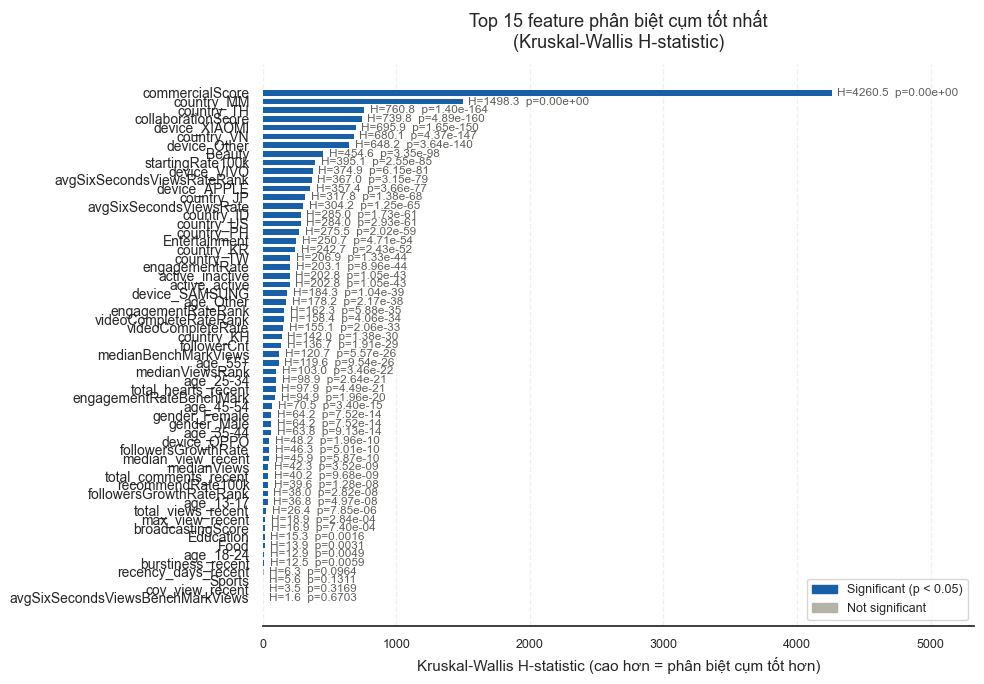

In [496]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

top_n = 84
top_df = kw_df.head(top_n).sort_values('H_statistic', ascending=True)

# Màu: nổi bật cho significant, mờ cho không đủ ý nghĩa
colors = [
    '#185FA5' if sig else '#B4B2A9'
    for sig in top_df['significant']
]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top_df['feature'],
    top_df['H_statistic'],
    color=colors,
    height=0.65,
    edgecolor='none'
)

# Ghi H-statistic và p-value lên từng bar
for bar, (_, row) in zip(bars, top_df.iterrows()):
    x_end = bar.get_width()
    p_str = f"p={row['p_value']:.2e}" if row['p_value'] < 0.001 else f"p={row['p_value']:.4f}"
    ax.text(
        x_end + max(top_df['H_statistic']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"H={x_end:.1f}  {p_str}",
        va='center', ha='left', fontsize=8.5,
        color='#5F5E5A'
    )

# Styling
ax.set_xlabel('Kruskal-Wallis H-statistic (cao hơn = phân biệt cụm tốt hơn)', fontsize=11)
ax.set_title('Top 15 feature phân biệt cụm tốt nhất\n(Kruskal-Wallis H-statistic)',
             fontsize=13, fontweight='medium', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.xaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Điều chỉnh xlim để nhãn không bị cắt
ax.set_xlim(0, max(top_df['H_statistic']) * 1.25)

# Legend
sig_patch   = mpatches.Patch(color='#185FA5', label='Significant (p < 0.05)')
insig_patch = mpatches.Patch(color='#B4B2A9', label='Not significant')
ax.legend(handles=[sig_patch, insig_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('kruskal_wallis_top15.png', dpi=150, bbox_inches='tight')
plt.show()

In [497]:

cluster_cols = [c for c in df.columns if c.startswith("cluster_")]

for c in cluster_cols:
    print(df[c].value_counts(dropna=False).sort_index())

cluster_kmeans
0     788
1    3966
2     322
3      13
Name: count, dtype: int64
cluster_hierarchical
0    3847
1     804
2     399
3      13
4      26
Name: count, dtype: int64
cluster_dbscan
-1     148
 0    4922
 1      19
Name: count, dtype: int64
cluster_spectral
0     548
1     775
2     791
3      90
4    2885
Name: count, dtype: int64
cluster_dbscan_7
-1      86
 0    4963
 1       6
 2      21
 3       3
 4       3
 5       4
 6       3
Name: count, dtype: int64
cluster_kmeans_8
0    3489
1      44
2     770
3      66
4     322
5      13
6      24
7     361
Name: count, dtype: int64


In [498]:
# cluster_col = "cluster_spectral" # tách 3 quy mô trên 5 cụm, có sự khác biệt giữa 3 quy mô
cluster_col = "cluster_kmeans" # Xu hướng của quy mô liên tục, nhưng có phân tách 
# cluster_col = "cluster_hierarchical" # 5 cụm nhưng quy mô hơi liên tục, có sự khác biệt 
# cluster_col = "cluster_dbscan" # 2 quy mô, phân tách cực đậm, rõ giữa 2  cụm , cụm -1 cũng rất hay.
# cluster_col = 'cluster_dbscan_7' # 
# cluster_col = 'cluster_kmeans_8'

In [499]:
cluster_cols = [c for c in df.columns if c.startswith("cluster_")]

feature_cols = [
    c for c in df.columns
    if c not in ["handleName"] + cluster_cols
    and pd.api.types.is_numeric_dtype(df[c])
]

print("Số biến dùng để trực quan:", len(feature_cols))
print(feature_cols)

Số biến dùng để trực quan: 59
['followerCnt', 'startingRate100k', 'recommendRate100k', 'followersGrowthRateRank', 'avgSixSecondsViewsRateRank', 'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank', 'avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews', 'engagementRateBenchMark', 'followersGrowthRate', 'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate', 'medianViews', 'broadcastingScore', 'collaborationScore', 'commercialScore', 'active_active', 'active_inactive', 'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54', 'age_Other', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO', 'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female', 'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW', 'country_KR', 'country_MM', 'country_KH', 'country_TH', 'country_PH', 'country_ID', 'Beauty', 'Education', 'Entertainment', 'Food', 'Sports', 'total_views_recent', 'total_hearts_recent', 'total_comments_recent', 'median_view_rec

In [500]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

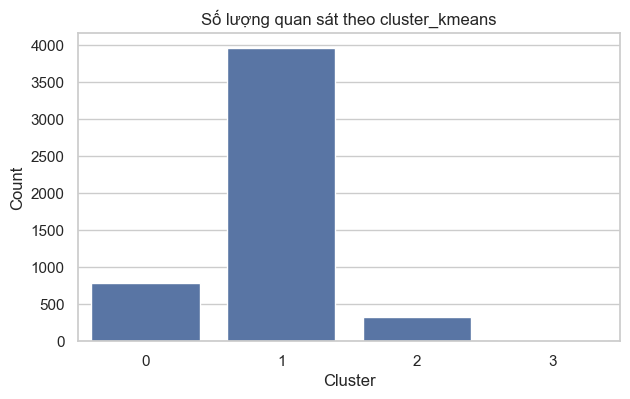

In [501]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x=cluster_col, order=sorted(df[cluster_col].dropna().unique()))
plt.title(f"Số lượng quan sát theo {cluster_col}")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

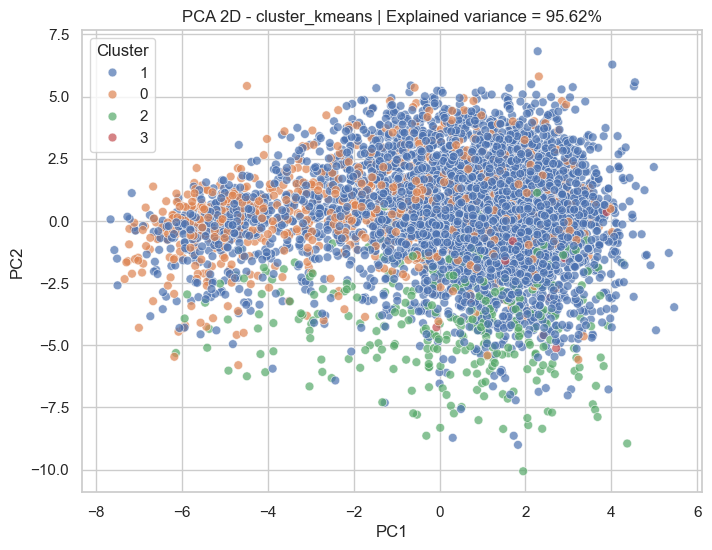

In [502]:

X = df[feature_cols].copy()

# nếu có NA thì thay bằng median
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df[cluster_col].astype(str)
})

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="Cluster",
    alpha=0.7,
    s=40
)
plt.title(f"PCA 2D - {cluster_col} | Explained variance = {pca.explained_variance_ratio_.sum():.2%}")
plt.show()

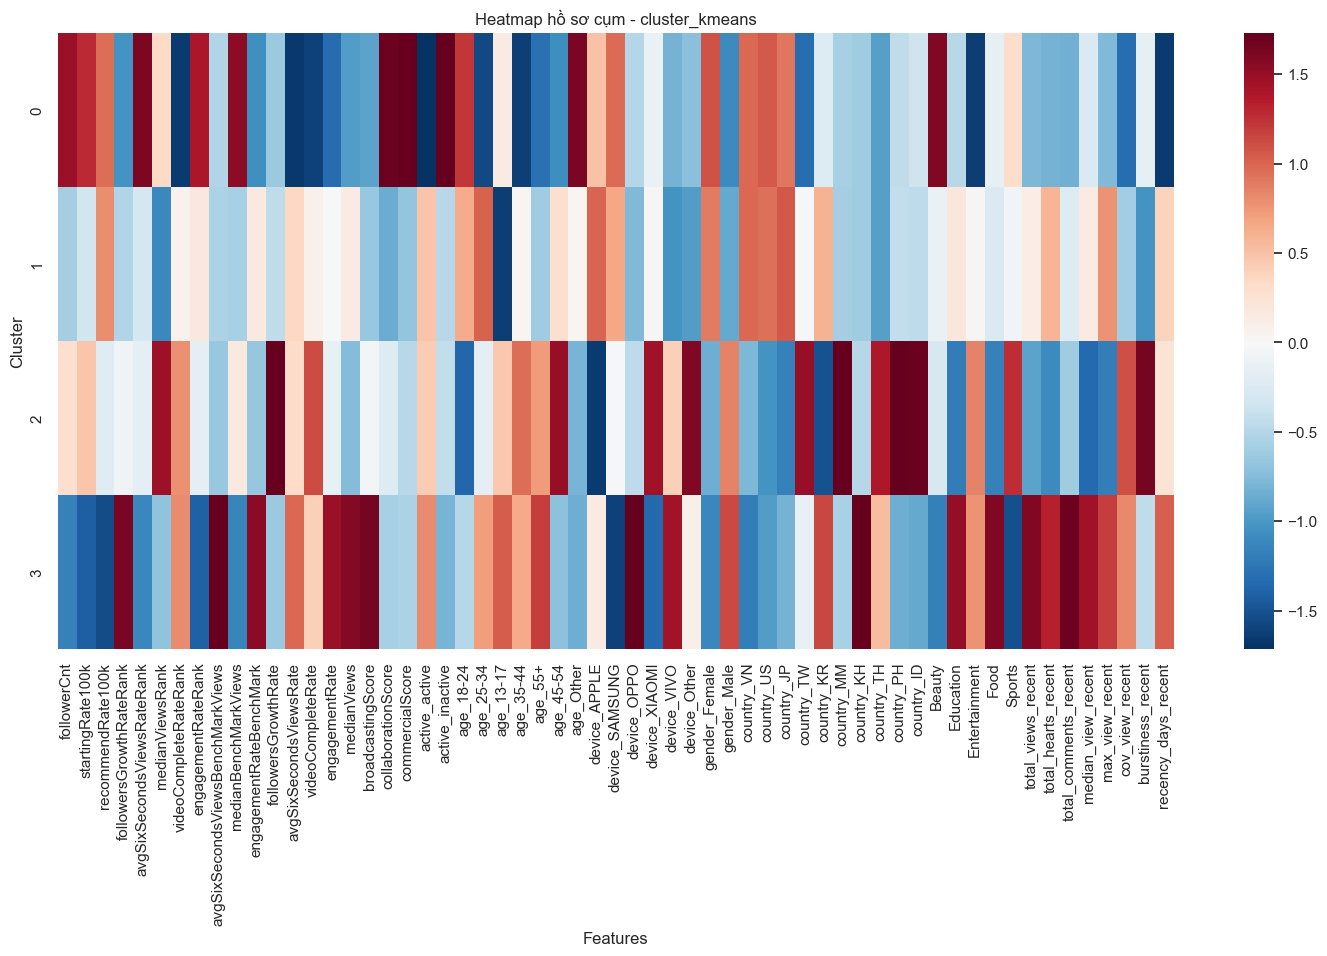

In [503]:
cluster_profile = df.groupby(cluster_col)[feature_cols].mean()

# chuẩn hóa theo cột để so sánh tương đối giữa các cụm
cluster_profile_z = (cluster_profile - cluster_profile.mean(axis=0)) / cluster_profile.std(axis=0, ddof=0)

plt.figure(figsize=(18, 8))
sns.heatmap(cluster_profile_z, cmap="RdBu_r", center=0, annot=False)
plt.title(f"Heatmap hồ sơ cụm - {cluster_col}")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

In [504]:
import pandas as pd
import numpy as np

# =========================
# 1. Chọn dữ liệu đầu vào
# =========================
# df_profile là dataframe đã có cột Cluster
# ví dụ: df_profile['Cluster']

cluster_col = 'cluster_kmeans'

key_cols = [
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'broadcastingScore',
    'collaborationScore',
    'commercialScore',
    'median_view_recent',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent'
]

# chỉ giữ những cột thật sự có trong df
key_cols = [col for col in key_cols if col in df.columns]

# kiểm tra
print("Số biến dùng để summary:", len(key_cols))
print("Các biến dùng:", key_cols)


# =========================
# 2. Bảng quy mô cụm
# =========================
cluster_size = (
    df[cluster_col]
    .value_counts(dropna=False)
    .sort_index()
    .rename('n_creator')
    .reset_index()
    .rename(columns={'index': cluster_col})
)

cluster_size['pct'] = cluster_size['n_creator'] / cluster_size['n_creator'].sum()

print("\n=== Cluster size ===")
print(cluster_size)


# =========================
# 3. Mean theo cluster
# =========================
cluster_mean = (
    df.groupby(cluster_col)[key_cols]
    .mean()
    .round(4)
)

print("\n=== Cluster mean ===")
display(cluster_mean)


# =========================
# 4. Median theo cluster
# =========================
cluster_median = (
    df.groupby(cluster_col)[key_cols]
    .median()
    .round(4)
)

print("\n=== Cluster median ===")
display(cluster_median)


# =========================
# 5. Std theo cluster (tùy chọn)
# =========================
cluster_std = (
    df.groupby(cluster_col)[key_cols]
    .std()
    .round(4)
)

print("\n=== Cluster std ===")
display(cluster_std)


# =========================
# 6. Gộp thành 1 bảng summary dài
# =========================
summary_rows = []

for clus, sub in df.groupby(cluster_col):  
    row = {
        cluster_col: clus,
        'n_creator': len(sub),
        'pct_creator': len(sub) / len(df)
    }
    
    for col in key_cols:
        row[f'{col}_mean'] = sub[col].mean()
        row[f'{col}_median'] = sub[col].median()
        row[f'{col}_std'] = sub[col].std()
    
    summary_rows.append(row)

cluster_summary = pd.DataFrame(summary_rows).sort_values(cluster_col).reset_index(drop=True)
cluster_summary = cluster_summary.round(4)

print("\n=== Cluster summary full ===")
display(cluster_summary)

Số biến dùng để summary: 10
Các biến dùng: ['followerCnt', 'followersGrowthRate', 'engagementRate', 'broadcastingScore', 'collaborationScore', 'commercialScore', 'median_view_recent', 'cov_view_recent', 'burstiness_recent', 'recency_days_recent']

=== Cluster size ===
   cluster_kmeans  n_creator       pct
0               0        788  0.154844
1               1       3966  0.779328
2               2        322  0.063274
3               3         13  0.002555

=== Cluster mean ===


,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
cluster_kmeans,,,,,,,,,,
0,623794.4150,0.0679,0.0415,87.2104,83.5853,90.5980,100677.5197,1.3134,-0.0384,4.1667
1,360449.6425,11.5788,0.0597,87.6327,74.2032,59.8132,105517.6010,1.3339,-0.0523,6.6853
2,472682.6335,131.8570,0.0577,88.5857,76.4658,62.3925,87059.4907,1.3830,-0.0100,6.4949
3,286518.8462,0.0556,0.0804,91.2462,75.2308,61.4769,121701.0769,1.3751,-0.0429,7.4758



=== Cluster median ===


,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
cluster_kmeans,,,,,,,,,,
0,231061.5,0.0000,0.0297,87.5,84.4,91.2,43961.0,1.1949,-0.0310,2.4977
1,150237.0,0.0046,0.0462,88.2,75.2,60.0,36293.5,1.2358,-0.0490,2.4968
2,238740.5,0.0102,0.0500,88.9,76.8,60.0,21904.0,1.2347,-0.0042,2.3927
3,97263.0,0.0137,0.0698,91.2,75.2,60.0,19262.0,1.3195,-0.0369,2.4930



=== Cluster std ===


,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
cluster_kmeans,,,,,,,,,,
0,1.423830e+06,0.8976,0.0480,6.5620,8.3646,5.4288,239960.4336,0.6931,0.1792,6.3641
1,8.156451e+05,635.0955,0.0489,9.0089,7.8369,4.7799,309298.2241,0.6224,0.2135,13.1221
2,9.511597e+05,2342.6186,0.0375,5.3248,6.4086,7.8573,350174.4956,0.7311,0.2587,11.7504
3,3.669387e+05,0.1296,0.0341,4.2349,4.1935,5.3251,268228.6406,0.4059,0.1781,8.3151



=== Cluster summary full ===


,cluster_kmeans,n_creator,pct_creator,followerCnt_mean,followerCnt_median,followerCnt_std,followersGrowthRate_mean,followersGrowthRate_median,followersGrowthRate_std,engagementRate_mean,...,median_view_recent_std,cov_view_recent_mean,cov_view_recent_median,cov_view_recent_std,burstiness_recent_mean,burstiness_recent_median,burstiness_recent_std,recency_days_recent_mean,recency_days_recent_median,recency_days_recent_std
0,0,788,0.1548,623794.4150,231061.5,1.423830e+06,0.0679,0.0000,0.8976,0.0415,...,239960.4336,1.3134,1.1949,0.6931,-0.0384,-0.0310,0.1792,4.1667,2.4977,6.3641
1,1,3966,0.7793,360449.6425,150237.0,8.156451e+05,11.5788,0.0046,635.0955,0.0597,...,309298.2241,1.3339,1.2358,0.6224,-0.0523,-0.0490,0.2135,6.6853,2.4968,13.1221
2,2,322,0.0633,472682.6335,238740.5,9.511597e+05,131.8570,0.0102,2342.6186,0.0577,...,350174.4956,1.3830,1.2347,0.7311,-0.0100,-0.0042,0.2587,6.4949,2.3927,11.7504
3,3,13,0.0026,286518.8462,97263.0,3.669387e+05,0.0556,0.0137,0.1296,0.0804,...,268228.6406,1.3751,1.3195,0.4059,-0.0429,-0.0369,0.1781,7.4758,2.4930,8.3151


In [505]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====== INPUT ======
# DataFrame chính của bạn
# giả sử tên là df_profile
# và cột cluster là 'cluster_kmeans'

cluster_col = 'cluster_kmeans'

cluster_name_map = {
    0: 'Commercial Mature Leaders',
    1: 'Mainstream Creator Base',
    2: 'Breakout Segment',
    3: 'High-Engagement Micro-Niche'
}

df = df.copy()

# gán tên cụm
df['cluster_name'] = df[cluster_col].map(cluster_name_map)

# thứ tự hiển thị
cluster_order = [0, 1, 2, 3]
cluster_labels = [cluster_name_map[c] for c in cluster_order]

print(df[[cluster_col, 'cluster_name']].drop_duplicates().sort_values(cluster_col))

     cluster_kmeans                 cluster_name
1                 0    Commercial Mature Leaders
0                 1      Mainstream Creator Base
9                 2             Breakout Segment
714               3  High-Engagement Micro-Niche


In [506]:
key_cols = [
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'broadcastingScore',
    'collaborationScore',
    'commercialScore',
    'median_view_recent',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent'
]

# chỉ giữ cột có thật trong df
key_cols = [c for c in key_cols if c in df.columns]

print("Biến dùng để trực quan:", key_cols)

Biến dùng để trực quan: ['followerCnt', 'followersGrowthRate', 'engagementRate', 'broadcastingScore', 'collaborationScore', 'commercialScore', 'median_view_recent', 'cov_view_recent', 'burstiness_recent', 'recency_days_recent']


In [507]:
cluster_size = (
    df.groupby([cluster_col, 'cluster_name'])
      .size()
      .reset_index(name='n_creator')
      .sort_values(cluster_col)
)

cluster_size['pct'] = cluster_size['n_creator'] / cluster_size['n_creator'].sum()

display(cluster_size)

,cluster_kmeans,cluster_name,n_creator,pct
0,0,Commercial Mature Leaders,788,0.154844
1,1,Mainstream Creator Base,3966,0.779328
2,2,Breakout Segment,322,0.063274
3,3,High-Engagement Micro-Niche,13,0.002555


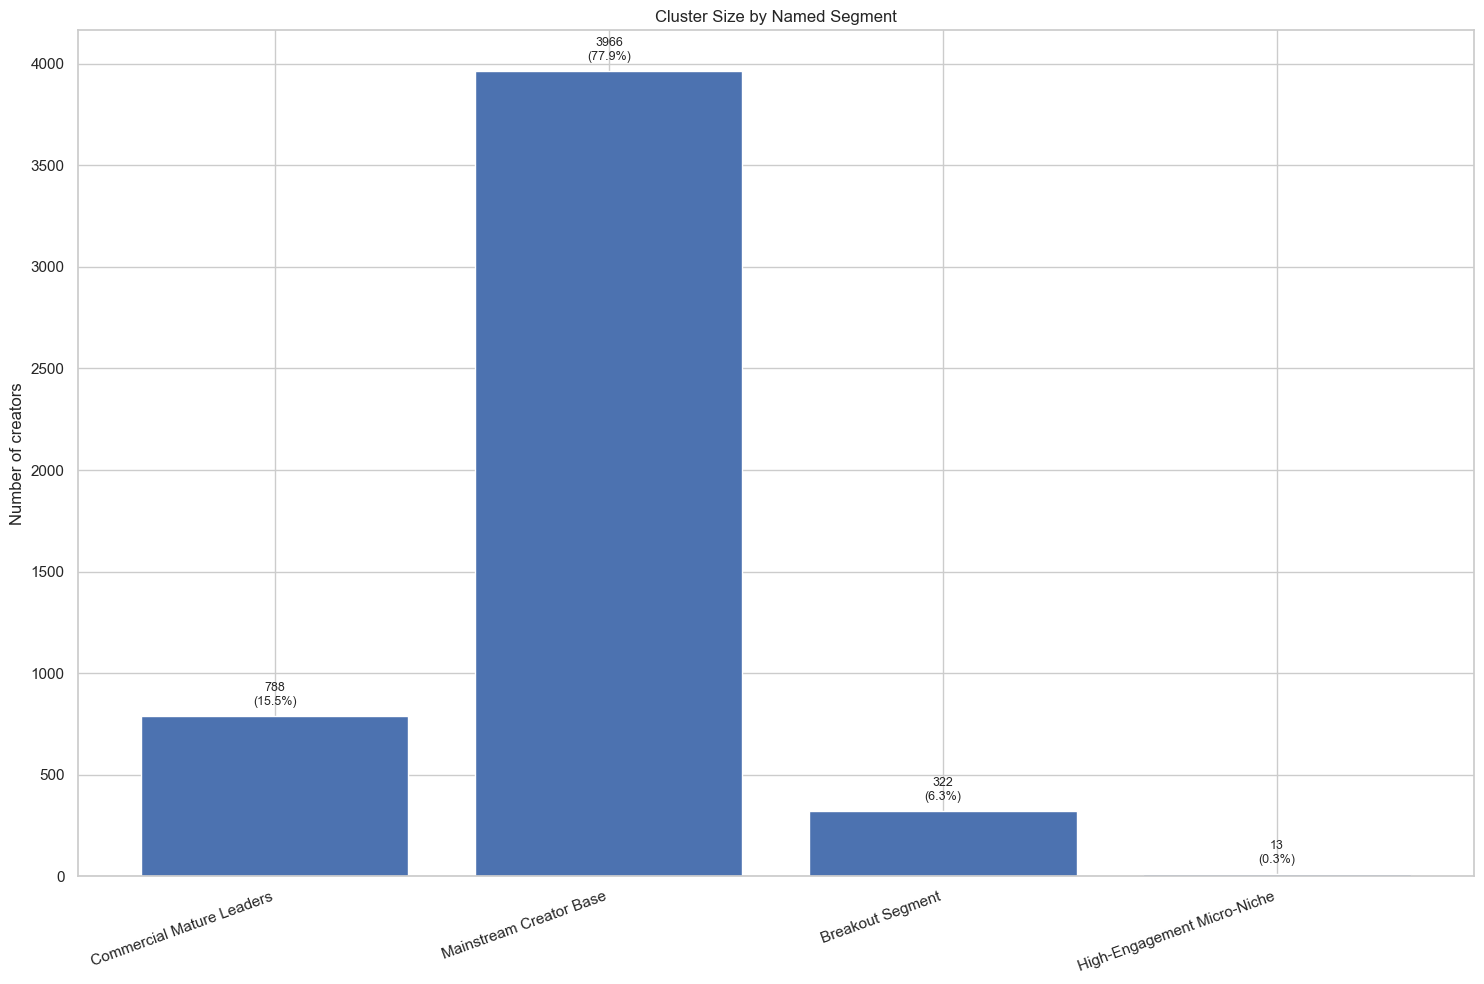

In [508]:
plt.figure(figsize=(15, 10))

plt.bar(cluster_size['cluster_name'], cluster_size['n_creator'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Number of creators')
plt.title('Cluster Size by Named Segment')

# ghi số lên cột
for i, row in cluster_size.iterrows():
    plt.text(i, row['n_creator'] + max(cluster_size['n_creator']) * 0.01,
             f"{row['n_creator']}\n({row['pct']:.1%})",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [509]:
cluster_mean_named = (
    df.groupby([cluster_col, 'cluster_name'])[key_cols]
      .mean()
      .reset_index()
      .sort_values(cluster_col)
)

cluster_median_named = (
    df.groupby([cluster_col, 'cluster_name'])[key_cols]
      .median()
      .reset_index()
      .sort_values(cluster_col)
)

display(cluster_mean_named)
display(cluster_median_named)

,cluster_kmeans,cluster_name,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
0,0,Commercial Mature Leaders,623794.414975,0.067950,0.041521,87.210406,83.585279,90.597970,100677.519670,1.313369,-0.038445,4.166663
1,1,Mainstream Creator Base,360449.642461,11.578777,0.059686,87.632728,74.203227,59.813212,105517.600983,1.333893,-0.052345,6.685332
2,2,Breakout Segment,472682.633540,131.857013,0.057747,88.585714,76.465839,62.392547,87059.490683,1.383030,-0.009987,6.494906
3,3,High-Engagement Micro-Niche,286518.846154,0.055641,0.080438,91.246154,75.230769,61.476923,121701.076923,1.375052,-0.042886,7.475752


,cluster_kmeans,cluster_name,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
0,0,Commercial Mature Leaders,231061.5,0.000009,0.02970,87.5,84.4,91.2,43961.0,1.194916,-0.030984,2.497708
1,1,Mainstream Creator Base,150237.0,0.004577,0.04620,88.2,75.2,60.0,36293.5,1.235818,-0.048970,2.496771
2,2,Breakout Segment,238740.5,0.010198,0.05005,88.9,76.8,60.0,21904.0,1.234680,-0.004156,2.392697
3,3,High-Engagement Micro-Niche,97263.0,0.013731,0.06980,91.2,75.2,60.0,19262.0,1.319528,-0.036880,2.492951


In [510]:
def zscore_by_column(dataframe, cols):
    out = dataframe.copy()
    for c in cols:
        mean_ = out[c].mean()
        std_ = out[c].std()
        if std_ == 0 or pd.isna(std_):
            out[c] = 0
        else:
            out[c] = (out[c] - mean_) / std_
    return out

def plot_heatmap(df_plot, value_cols, title, figsize=(12, 5), annotate=True):
    values = df_plot[value_cols].values
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(values, aspect='auto')

    ax.set_xticks(np.arange(len(value_cols)))
    ax.set_xticklabels(value_cols, rotation=45, ha='right')

    ax.set_yticks(np.arange(len(df_plot)))
    ax.set_yticklabels(df_plot['cluster_name'])

    ax.set_title(title)

    # ghi số trong từng ô
    if annotate:
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                ax.text(j, i, f"{values[i, j]:.2f}",
                        ha='center', va='center', fontsize=8)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Z-score')

    plt.tight_layout()
    plt.show()

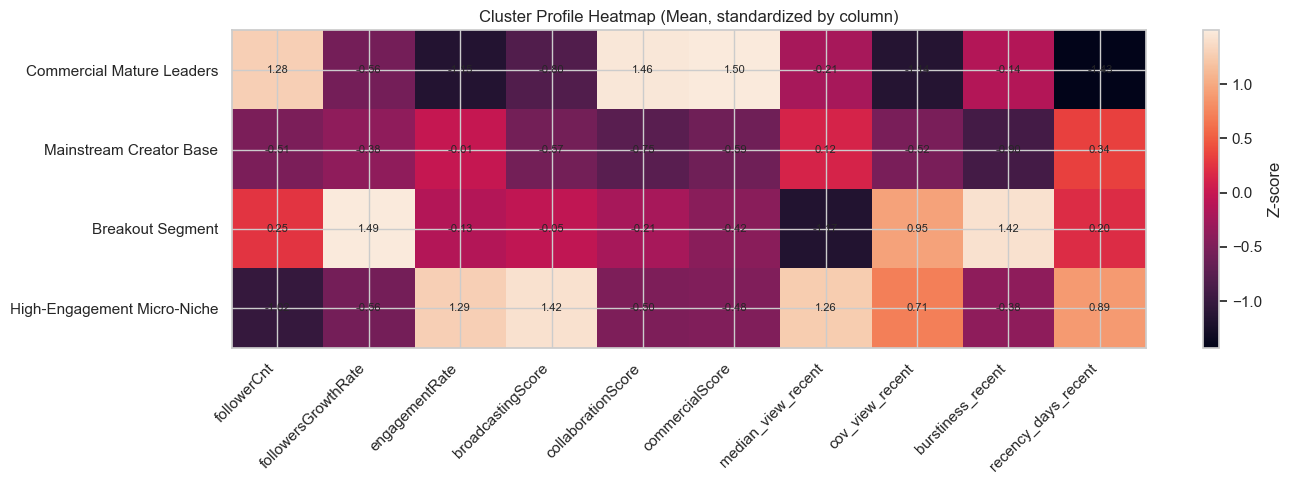

In [511]:
mean_for_heatmap = cluster_mean_named.copy()
mean_for_heatmap = zscore_by_column(mean_for_heatmap, key_cols)

plot_heatmap(
    mean_for_heatmap,
    value_cols=key_cols,
    title='Cluster Profile Heatmap (Mean, standardized by column)',
    figsize=(14, 5),
    annotate=True
)

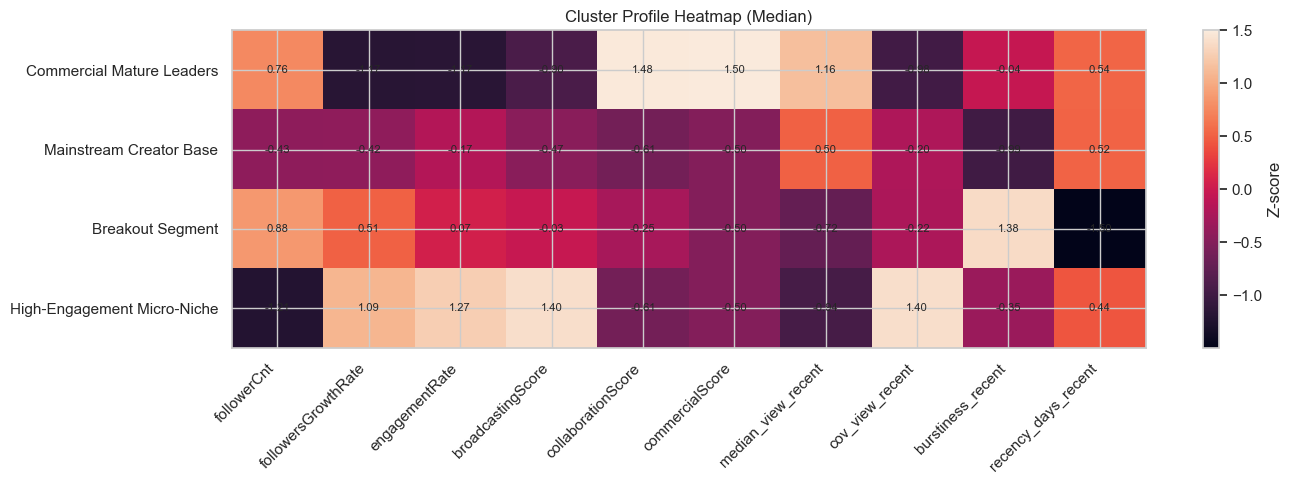

In [512]:
median_for_heatmap = cluster_median_named.copy()
median_for_heatmap = zscore_by_column(median_for_heatmap, key_cols)

plot_heatmap(
    median_for_heatmap,
    value_cols=key_cols,
    title='Cluster Profile Heatmap (Median)',
    figsize=(14, 5),
    annotate=True
)


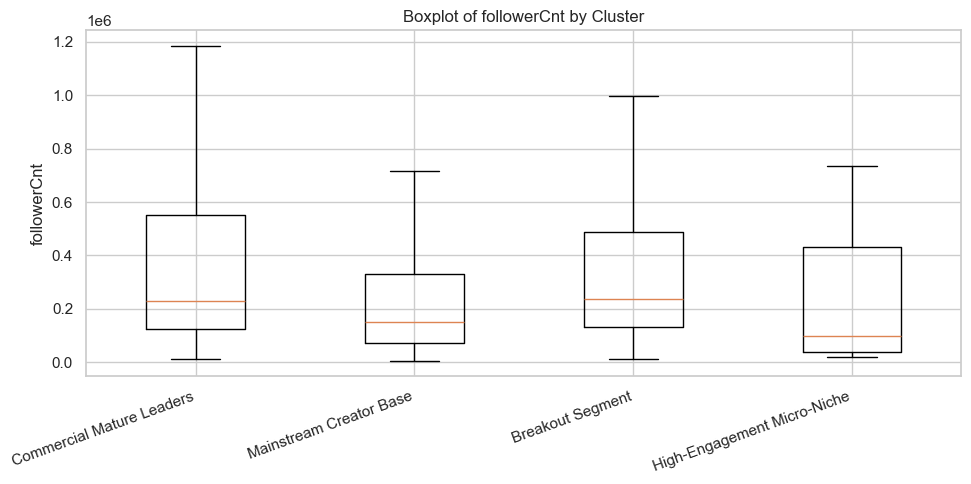

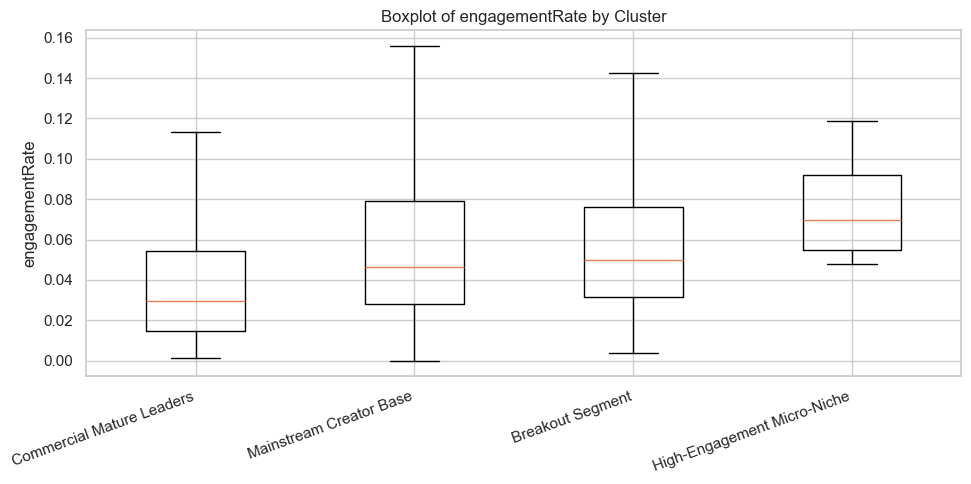

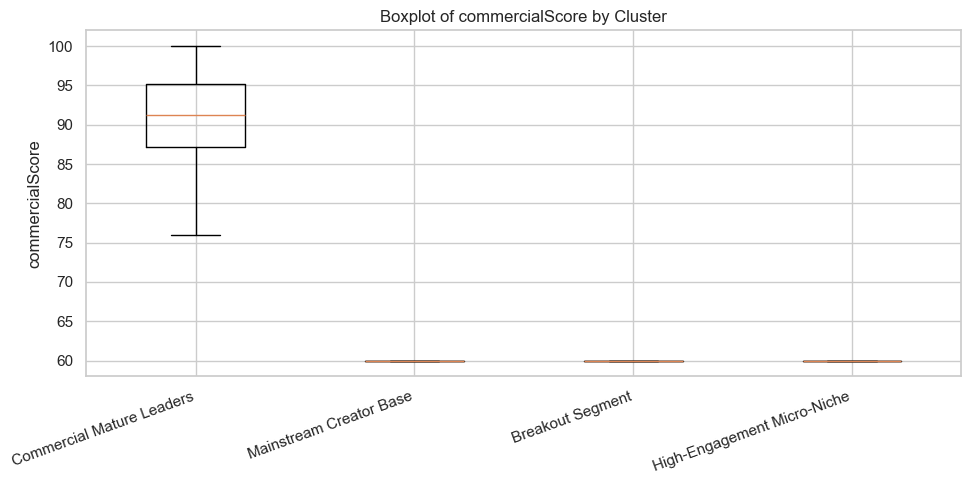

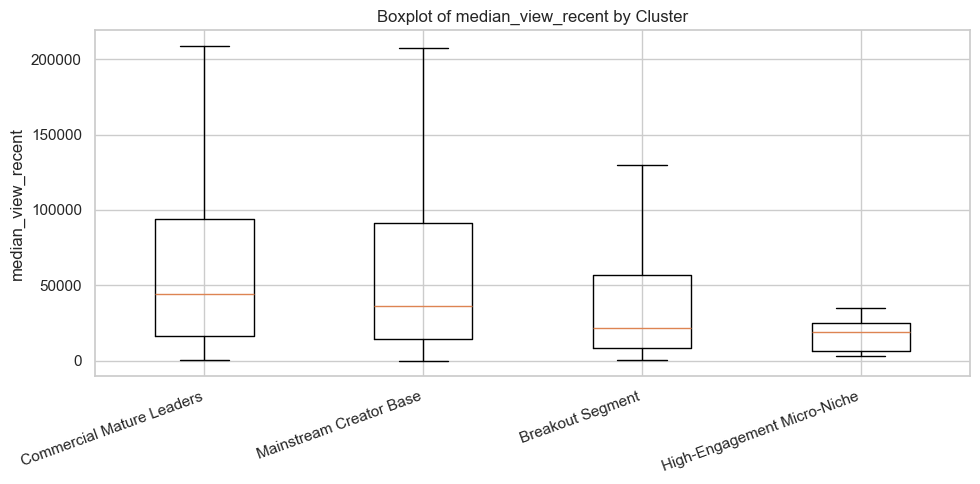

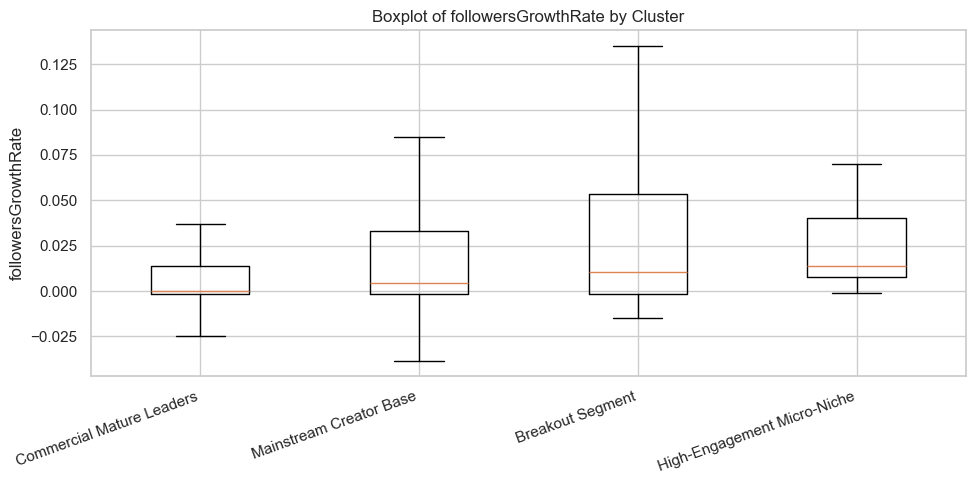

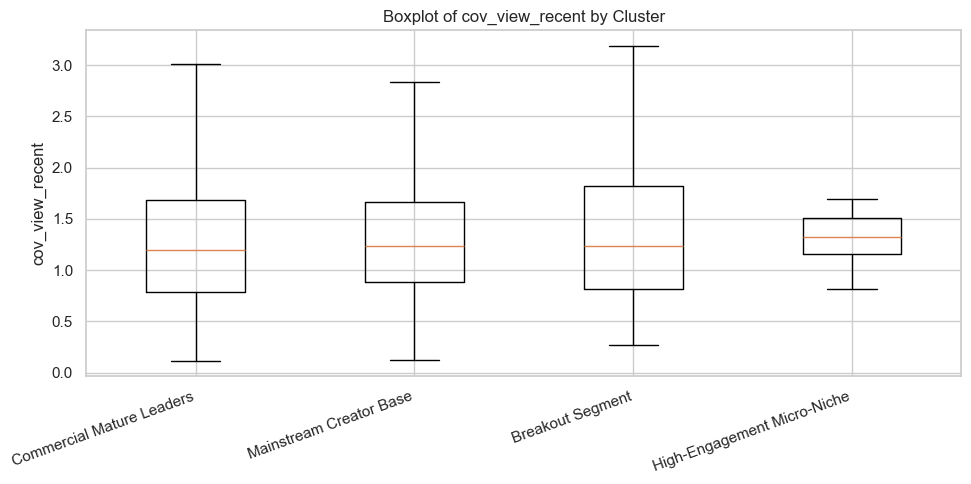

In [513]:
plot_cols = [
    'followerCnt',
    'engagementRate',
    'commercialScore',
    'median_view_recent',
    'followersGrowthRate',
    'cov_view_recent'
]

plot_cols = [c for c in plot_cols if c in df.columns]

for col in plot_cols:
    plt.figure(figsize=(10, 5))
    
    data_to_plot = [
        df.loc[df[cluster_col] == c, col].dropna().values
        for c in cluster_order
    ]
    
    plt.boxplot(data_to_plot, labels=cluster_labels, showfliers=False)
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Boxplot of {col} by Cluster')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

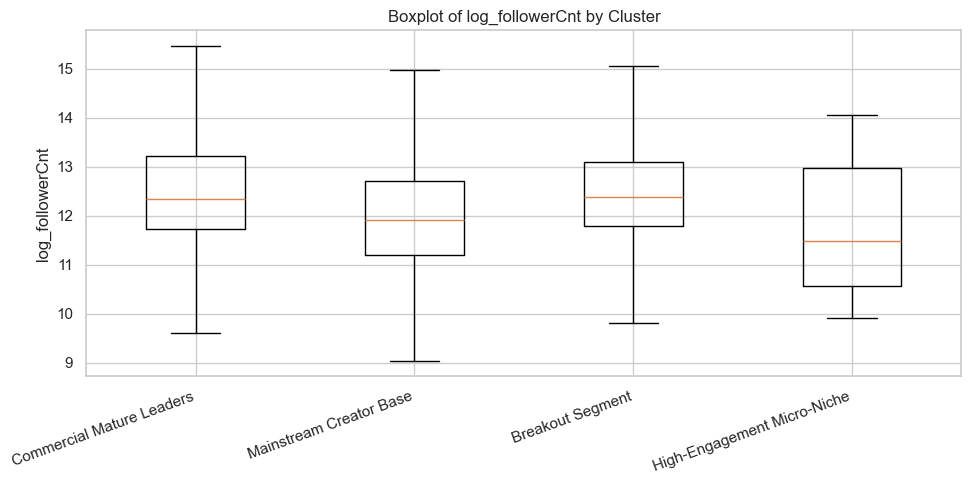

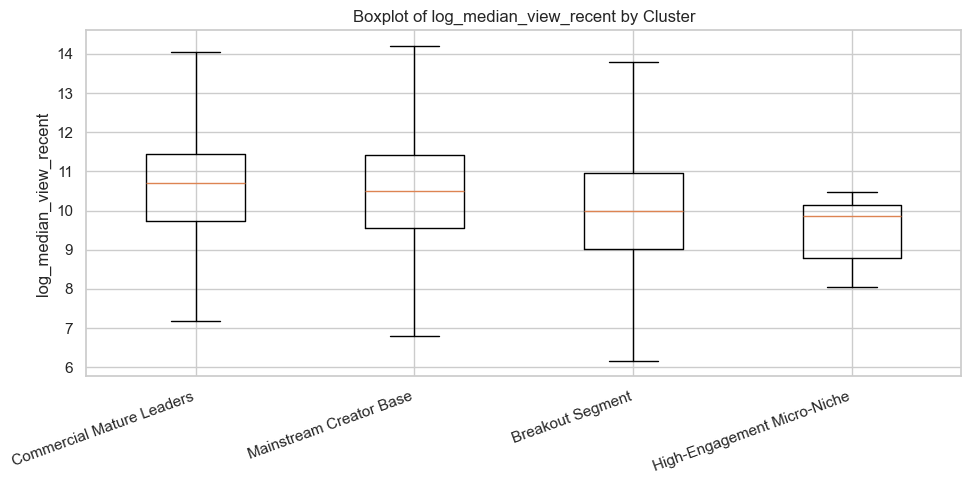

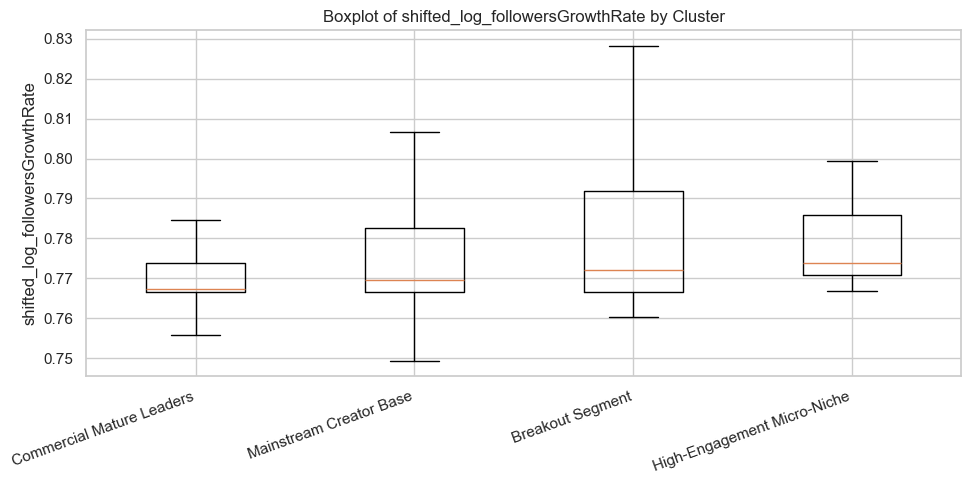

In [514]:
df['log_followerCnt'] = np.log1p(df['followerCnt']) if 'followerCnt' in df.columns else np.nan
df['log_median_view_recent'] = np.log1p(df['median_view_recent']) if 'median_view_recent' in df.columns else np.nan

# followersGrowthRate có thể có giá trị âm hoặc gần 0, nên cần cẩn thận
if 'followersGrowthRate' in df.columns:
    min_val = df['followersGrowthRate'].min()
    shift = 1 - min_val if min_val <= 0 else 0
    df['shifted_log_followersGrowthRate'] = np.log1p(df['followersGrowthRate'] + shift)

extra_plot_cols = ['log_followerCnt', 'log_median_view_recent', 'shifted_log_followersGrowthRate']
extra_plot_cols = [c for c in extra_plot_cols if c in df.columns]

for col in extra_plot_cols:
    plt.figure(figsize=(10, 5))
    
    data_to_plot = [
        df.loc[df[cluster_col] == c, col].dropna().values
        for c in cluster_order
    ]
    
    plt.boxplot(data_to_plot, labels=cluster_labels, showfliers=False)
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Boxplot of {col} by Cluster')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

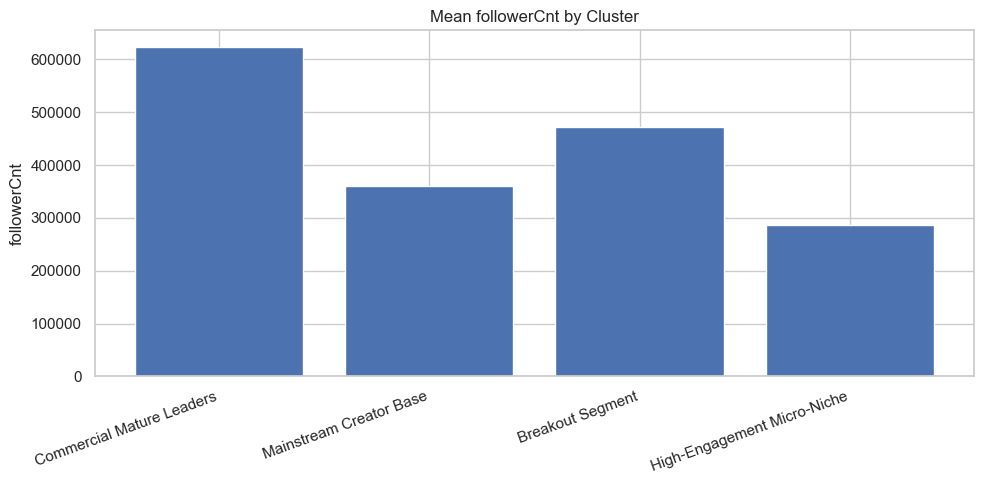

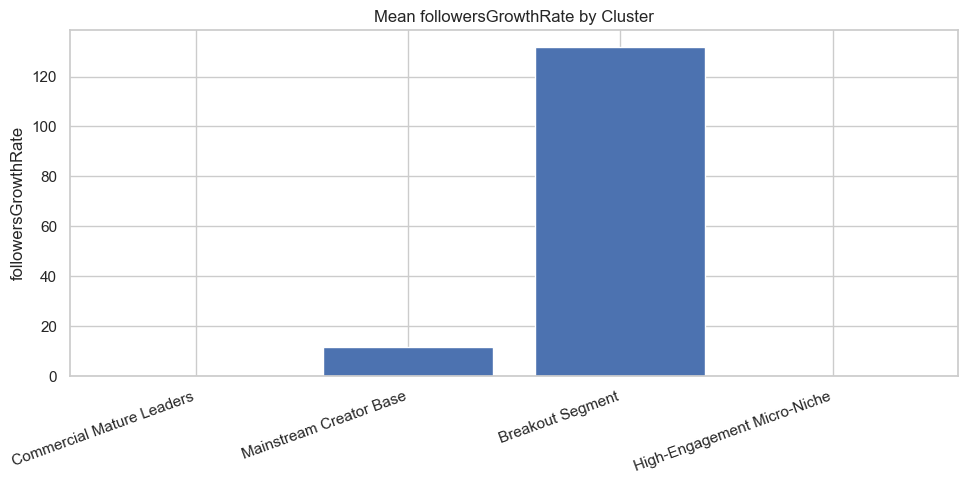

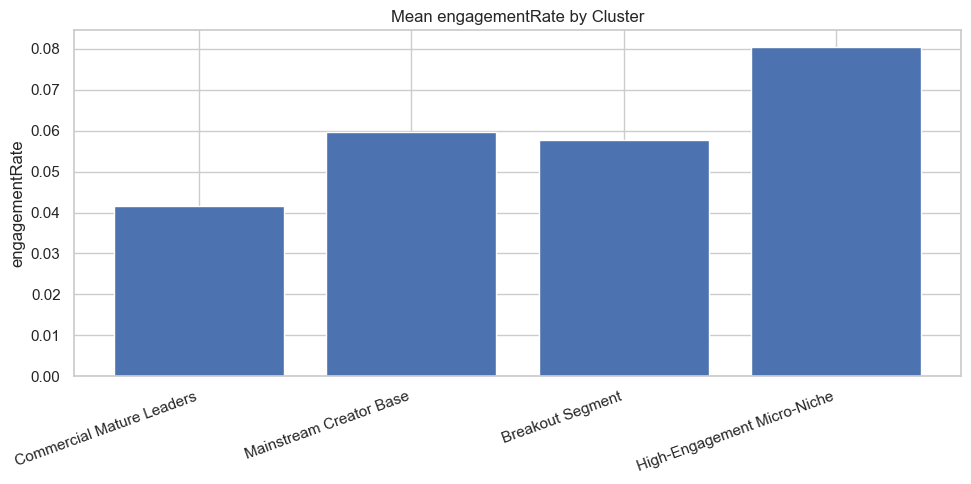

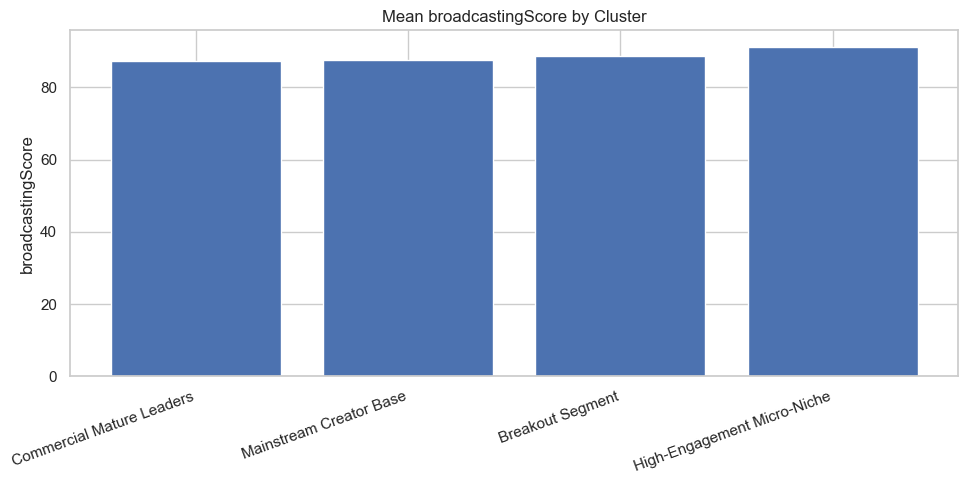

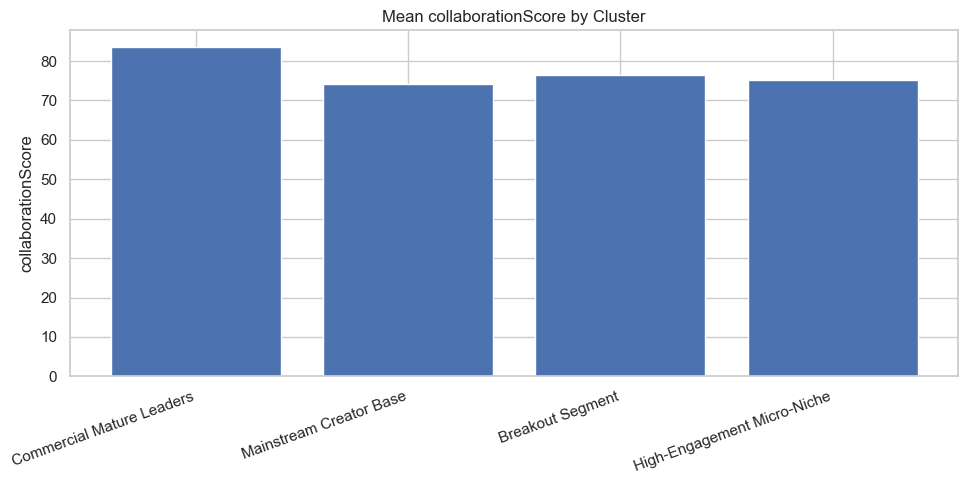

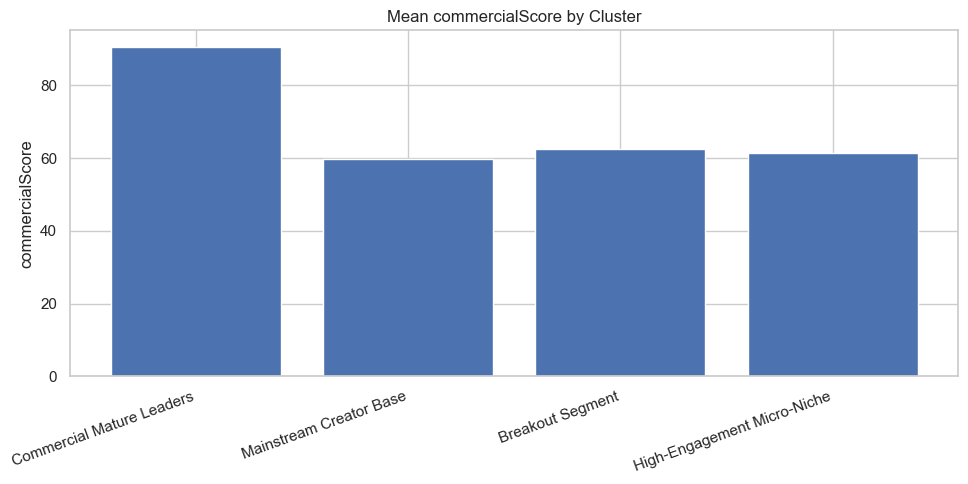

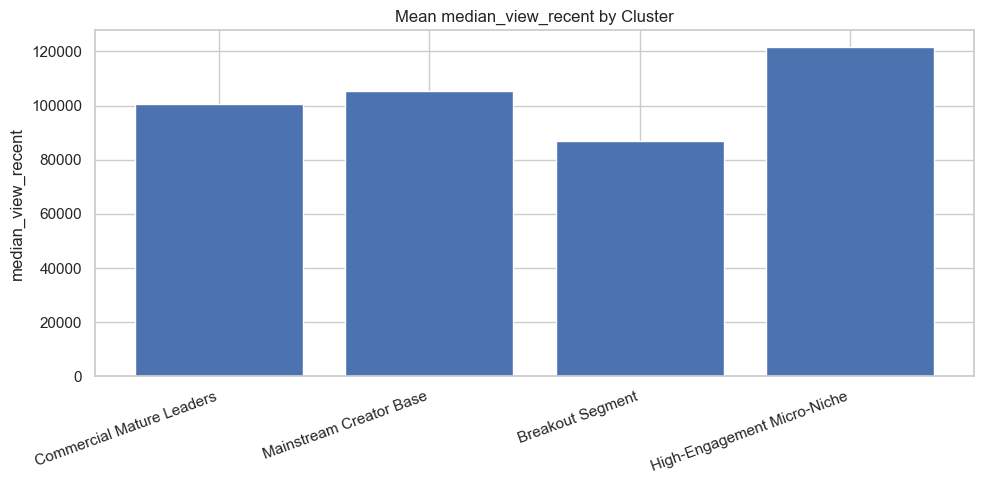

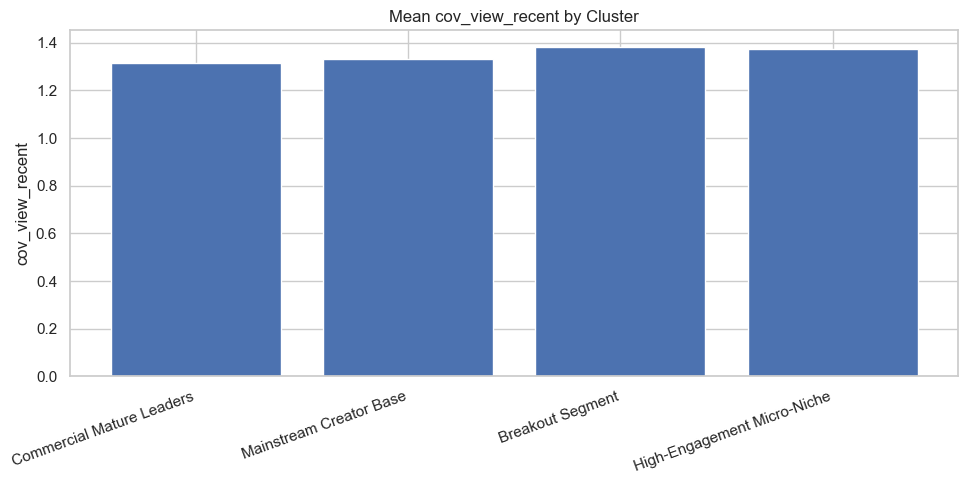

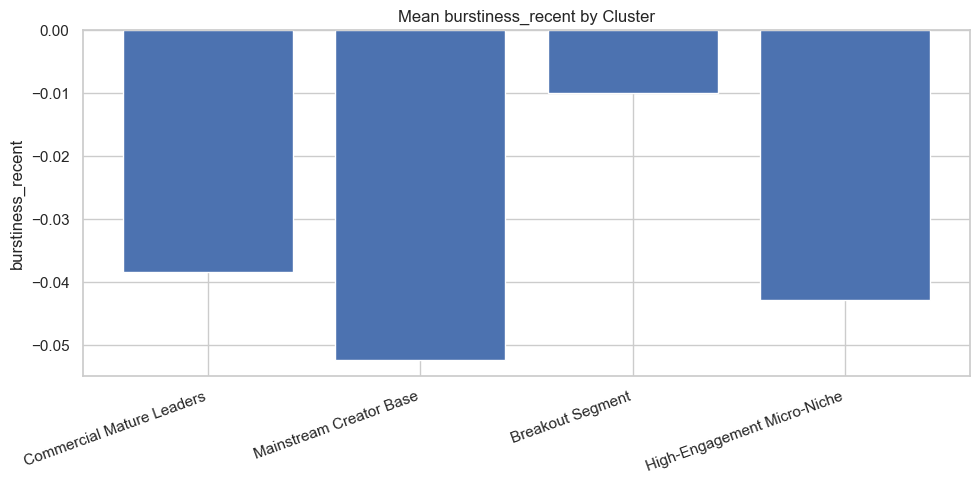

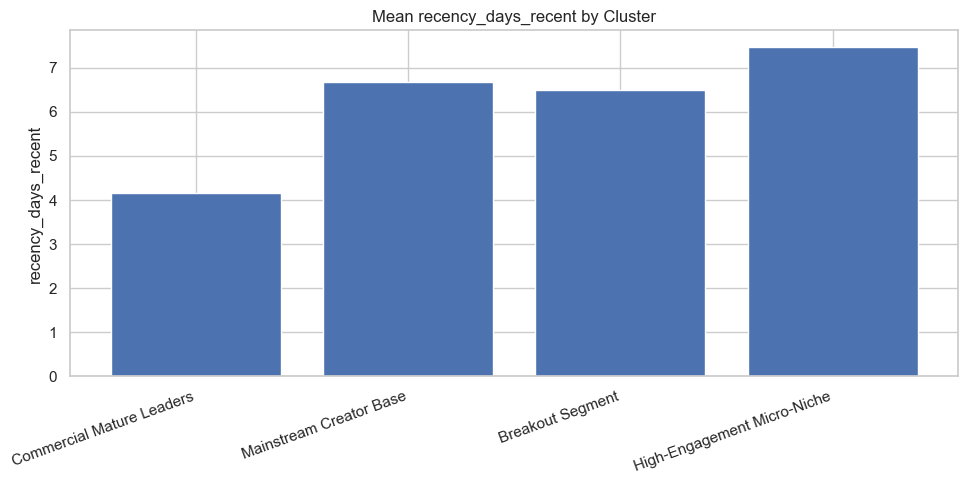

In [515]:
for col in key_cols:
    tmp = (
        df.groupby([cluster_col, 'cluster_name'])[col]
          .mean()
          .reset_index()
          .sort_values(cluster_col)
    )
    
    plt.figure(figsize=(10, 5))
    plt.bar(tmp['cluster_name'], tmp[col])
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Mean {col} by Cluster')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

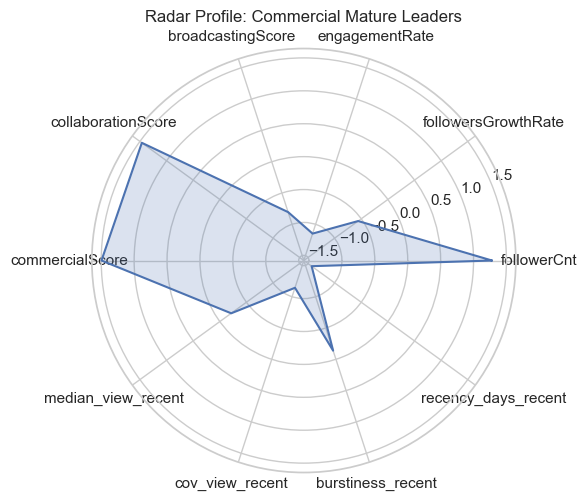

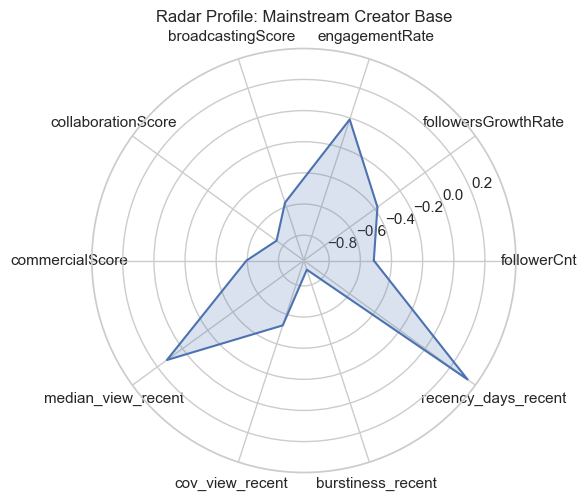

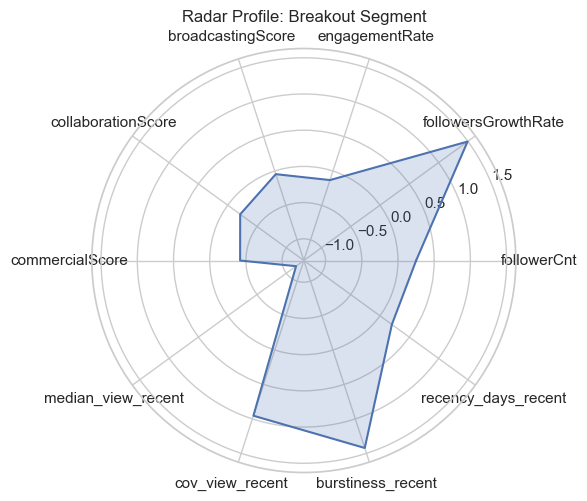

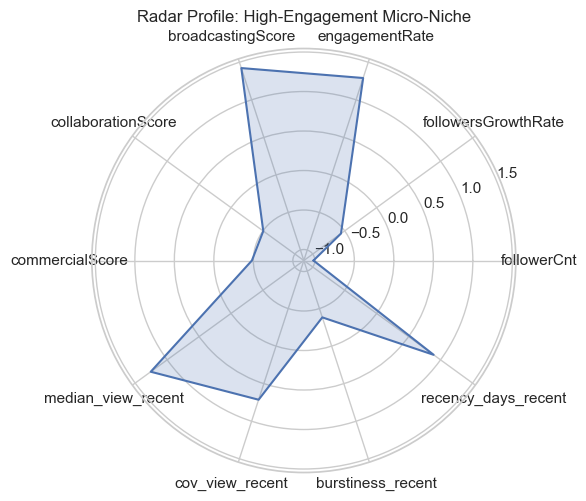

In [516]:
# chuẩn hóa mean theo z-score để radar có cùng scale
radar_df = cluster_mean_named.copy()
radar_df = zscore_by_column(radar_df, key_cols)

labels = key_cols
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for _, row in radar_df.iterrows():
    values = row[key_cols].tolist()
    values += values[:1]
    
    fig = plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(f"Radar Profile: {row['cluster_name']}")
    
    plt.tight_layout()
    plt.show()

In [517]:
feature_diff = (cluster_profile.max(axis=0) - cluster_profile.min(axis=0)).sort_values(ascending=False)

top_features = feature_diff.head(8).index.tolist()

print("Top biến khác nhau mạnh nhất giữa các cụm:")
print(feature_diff.head(8))

Top biến khác nhau mạnh nhất giữa các cụm:
startingRate100k       6.141085e+11
recommendRate100k      1.457682e+11
total_views_recent     1.116601e+06
followerCnt            3.372756e+05
max_view_recent        1.425216e+05
total_hearts_recent    3.617967e+04
median_view_recent     3.464159e+04
medianViews            1.976983e+04
dtype: float64


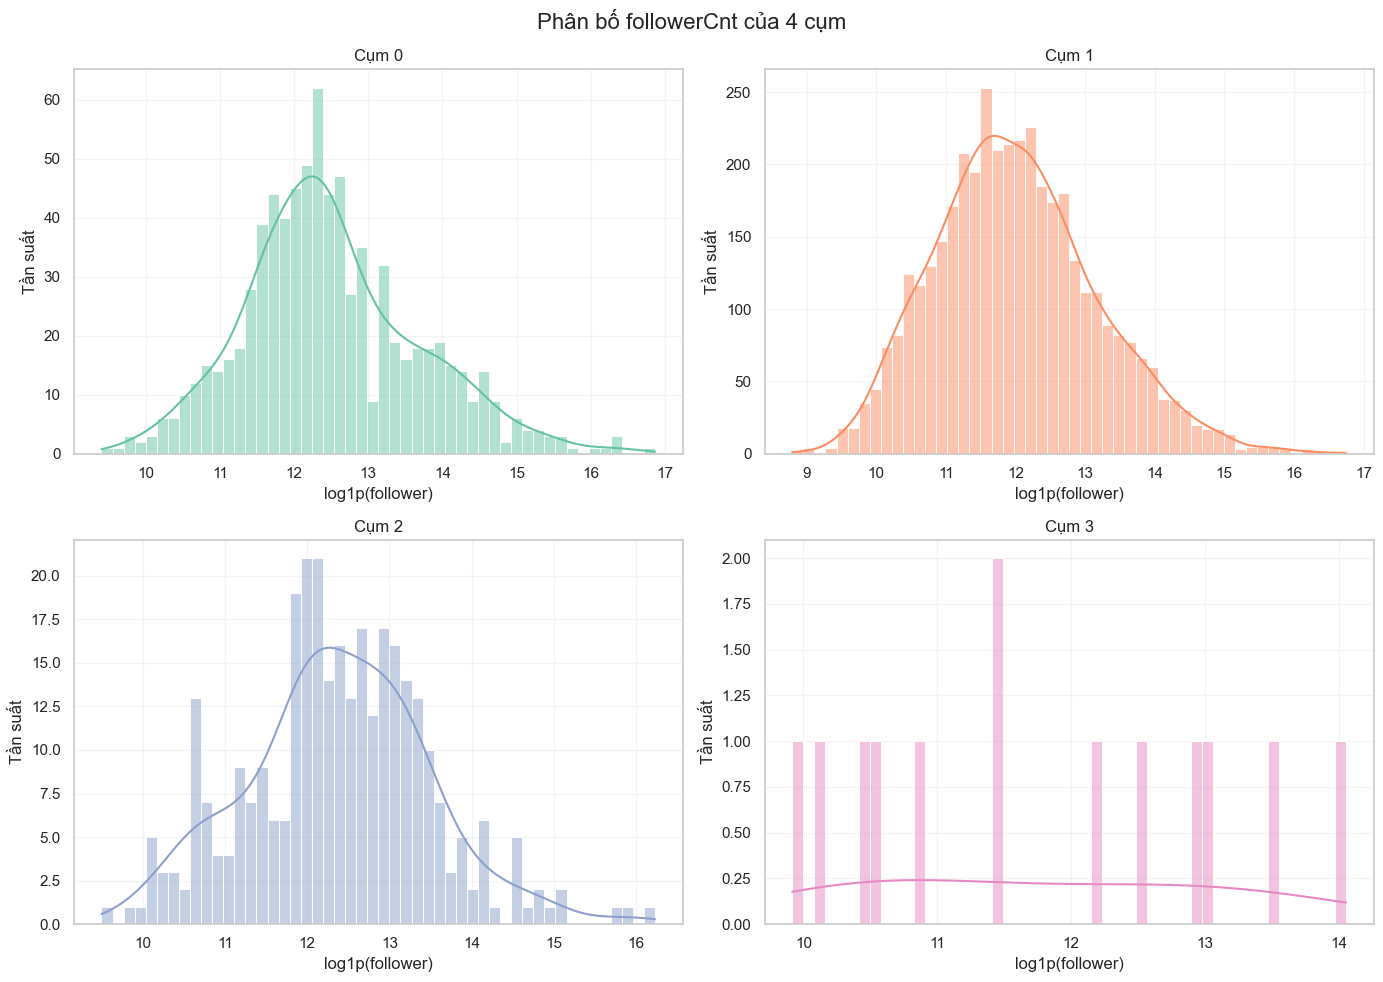

In [518]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

x_col = 'cluster_kmeans'
y_col = 'followerCnt'

# lọc dữ liệu hợp lệ
plot_df = df[[x_col, y_col]].dropna().copy()
plot_df = plot_df[plot_df[y_col] >= 0]

# vì followerCnt thường lệch phải mạnh, dùng log1p để histogram dễ đọc hơn
plot_df['followerCnt_log'] = np.log1p(plot_df[y_col])

clusters = sorted(plot_df[x_col].unique())[:4]
colors = sns.color_palette("Set2", n_colors=4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, clus in enumerate(clusters):
    sub = plot_df[plot_df[x_col] == clus]
    
    sns.histplot(
        sub['followerCnt_log'],
        bins=50,
        kde=True,
        ax=axes[i],
        color=colors[i]
    )
    
    axes[i].set_title(f'Cụm {clus}')
    axes[i].set_xlabel('log1p(follower)')
    axes[i].set_ylabel('Tần suất')
    axes[i].grid(alpha=0.2)

plt.suptitle('Phân bố followerCnt của 4 cụm', fontsize=16)
plt.tight_layout()
plt.show()

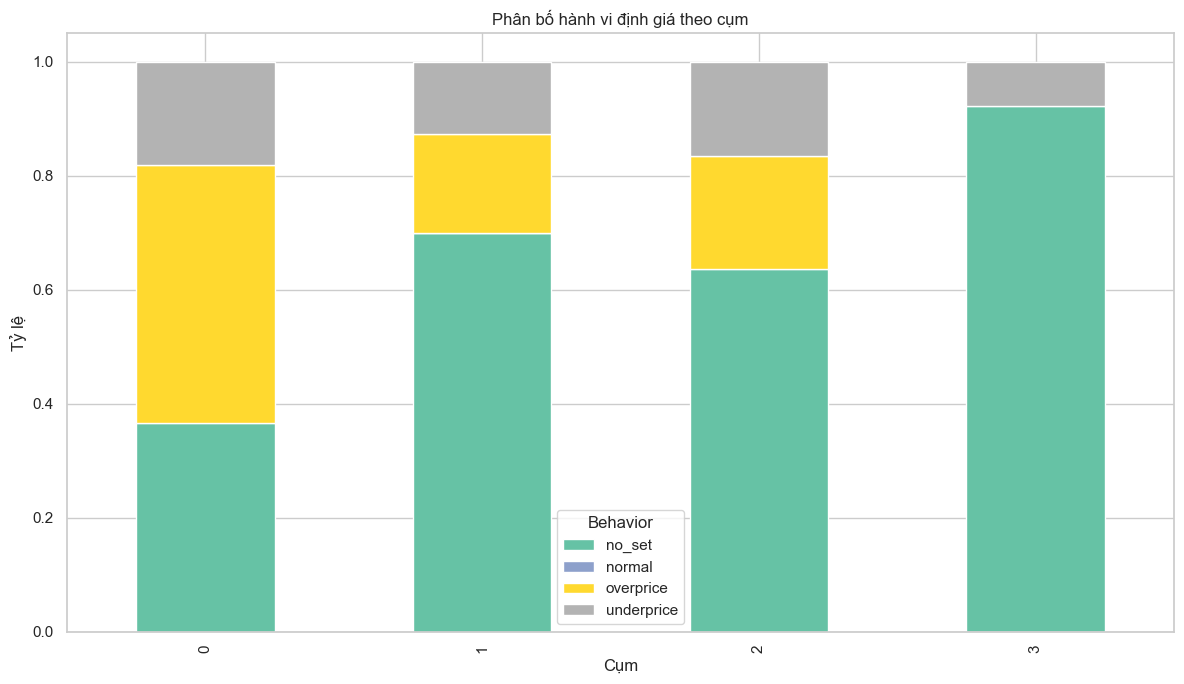

In [519]:
df['pricing_behavior'] = 'normal'

df.loc[
    df['startingRate100k'].isna() | (df['startingRate100k'] == 0),
    'pricing_behavior'
] = 'no_set'

df.loc[
    df['startingRate100k'] > df['recommendRate100k'],
    'pricing_behavior'
] = 'overprice'

df.loc[
    (df['startingRate100k'] < df['recommendRate100k']) &
    (df['pricing_behavior'] != 'no_set'),
    'pricing_behavior'
] = 'underprice'

ratio = (
    df.groupby(['cluster_kmeans', 'pricing_behavior'])
      .size()
      .unstack(fill_value=0)
)
ratio = ratio.div(ratio.sum(axis=1), axis=0)  # chuyển thành %

ratio.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='Set2'
)

plt.title('Phân bố hành vi định giá theo cụm')
plt.xlabel('Cụm')
plt.ylabel('Tỷ lệ')
plt.legend(title='Behavior')
plt.tight_layout()
plt.show()

Cụm nào có followersGrowthRateRank cao nhưng videoCompleteRateRank thấp? → Đang mua/boost follower hoặc tăng trưởng không bền.
Cụm nào có videoCompleteRateRank cao nhưng medianViewsRank thấp? → Nội dung chất lượng nhưng chưa được phân phối — tiềm năng bị bỏ qua.

In [520]:
df['gap_views_vs_engagement'] = df['medianViewsRank'] - df['engagementRateRank']

df['gap_growth_vs_completion'] = df['followersGrowthRateRank'] - df['videoCompleteRateRank']

df['gap_quality_vs_distribution'] = df['videoCompleteRateRank'] - df['medianViewsRank']

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\2062749288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


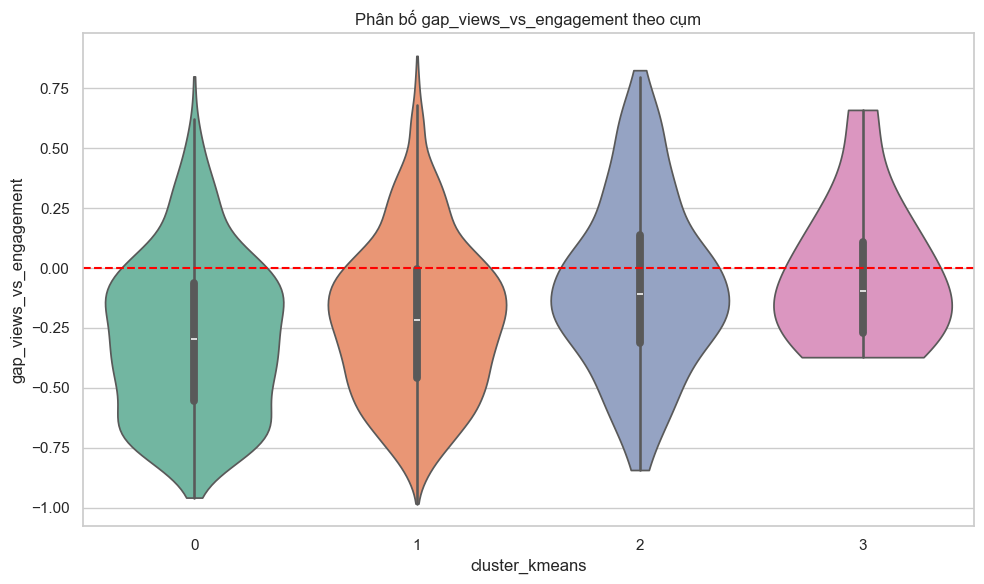

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\2062749288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


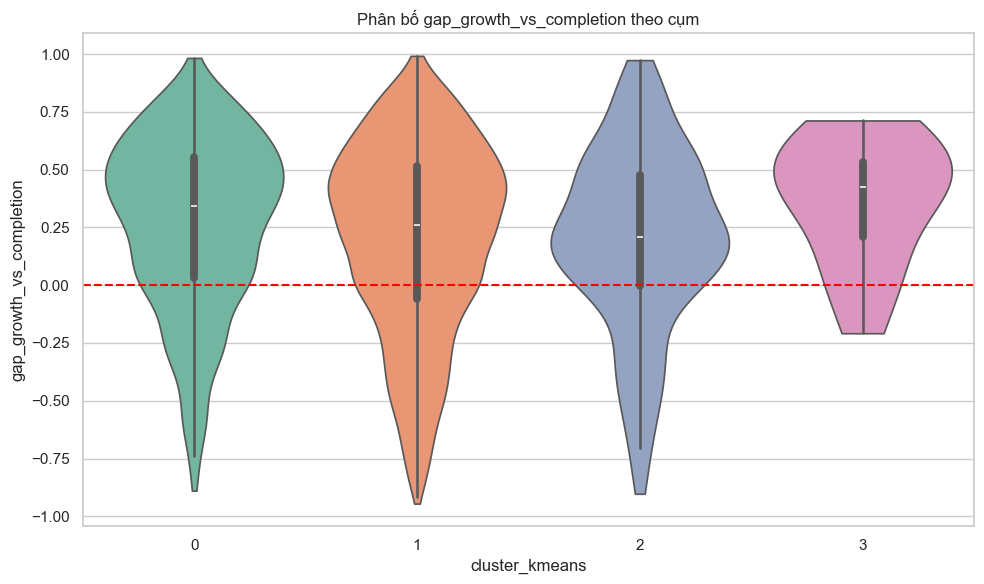

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\2062749288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


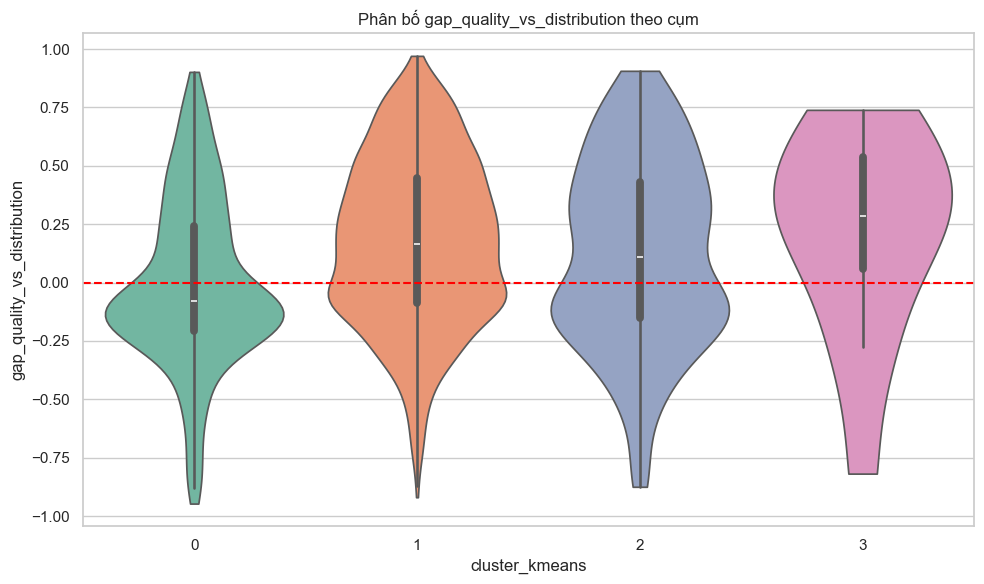

In [521]:

gaps = [
    'gap_views_vs_engagement', # nhiều view nhưng ko tương tác
    'gap_growth_vs_completion', # Tăng follower nhưng ko có ai xem video ddeesn cuối  
    'gap_quality_vs_distribution'  # Xem hết  video nhưng lượt view thấp , ndung tốt nhưng ko ai xem nhiều 
]

for gap in gaps:
    plt.figure(figsize=(10, 6))
    
    sns.violinplot(
        data=df,
        x='cluster_kmeans',
        y=gap,
        inner='box',
        palette='Set2',
        cut=0
    )
    
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Phân bố {gap} theo cụm')
    plt.tight_layout()
    plt.show()

In [522]:

eps = 1e-9

df['lift_avg6s_views'] = (
    (df['avgSixSecondsViewsRate'] - df['avgSixSecondsViewsBenchMarkViews']) /
    (df['avgSixSecondsViewsBenchMarkViews'] + eps)
)

df['lift_median_views'] = (
    (df['medianViews'] - df['medianBenchMarkViews']) /
    (df['medianBenchMarkViews'] + eps)
)

df['lift_engagement'] = (
    (df['engagementRate'] - df['engagementRateBenchMark']) /
    (df['engagementRateBenchMark'] + eps)
)
heatmap_df = (
    df.groupby('cluster_kmeans')[
        ['lift_avg6s_views', 'lift_median_views', 'lift_engagement']
    ]
    .median()
)

heatmap_df

,lift_avg6s_views,lift_median_views,lift_engagement
cluster_kmeans,,,
0,-0.392061,3.736800,-0.281250
1,-0.031550,6.024443,0.077684
2,-0.078302,2.046748,0.185635
3,0.012078,12.584859,0.579918


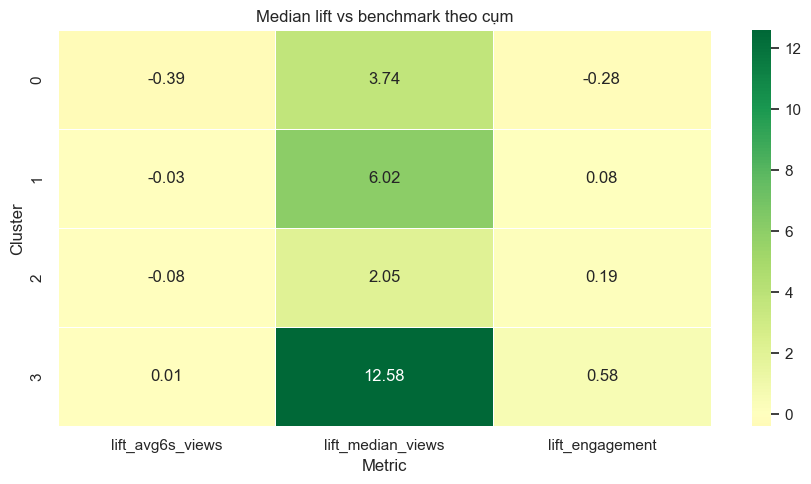

In [523]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title('Median lift vs benchmark theo cụm')
plt.xlabel('Metric')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

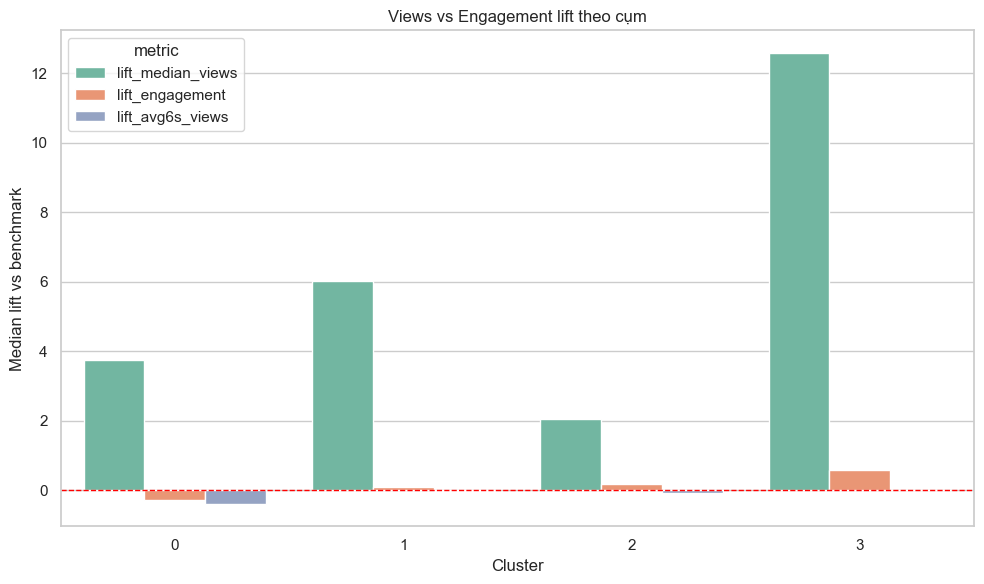

In [524]:
plot_df = (
    df.groupby('cluster_kmeans')[['lift_median_views', 'lift_engagement','lift_avg6s_views']]
    .median()
    .reset_index()
    .melt(id_vars='cluster_kmeans', var_name='metric', value_name='lift')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x='cluster_kmeans',
    y='lift',
    hue='metric',
    palette='Set2'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Views vs Engagement lift theo cụm')
plt.xlabel('Cluster')
plt.ylabel('Median lift vs benchmark')
plt.tight_layout()
plt.show()

In [525]:

# ví dụ trọng số
w1 = 1.0   # Apple
w2 = 0.8   # Samsung
w3 = 0.4  # Oppo/Xiaomi/Vivo

df['device_value_segment'] = (
    df['device_OPPO'] + df['device_XIAOMI'] + df['device_VIVO']
)

df['purchase_power_index'] = (
    df['device_APPLE'] * w1
    + df['device_SAMSUNG'] * w2
    + df['device_value_segment'] * w3
)

In [526]:
cluster_device_summary = (
    df.groupby('cluster_kmeans')
      .agg(
          n=('handleName', 'count'),
          purchase_power_mean=('purchase_power_index', 'mean'),
          purchase_power_median=('purchase_power_index', 'median'),
          apple_mean=('device_APPLE', 'mean'),
          samsung_mean=('device_SAMSUNG', 'mean'),
          value_segment_mean=('device_value_segment', 'mean'),
          other_mean=('device_Other', 'mean')
      )
      .sort_values('purchase_power_median', ascending=False)
)

print(cluster_device_summary)

                   n  purchase_power_mean  purchase_power_median  apple_mean  \
cluster_kmeans                                                                 
1               3966             0.695254               0.700000    0.411137   
0                788             0.677125               0.675915    0.377646   
3                 13             0.591429               0.585456    0.353473   
2                322             0.532871               0.531626    0.232326   

                samsung_mean  value_segment_mean  other_mean  
cluster_kmeans                                                
1                   0.196777            0.316739    0.070213  
0                   0.211231            0.326237    0.079511  
3                   0.091819            0.411251    0.111129  
2                   0.164853            0.421657    0.168744  


C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\1998204924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='cluster_kmeans', y='purchase_power_index', palette='Set2')


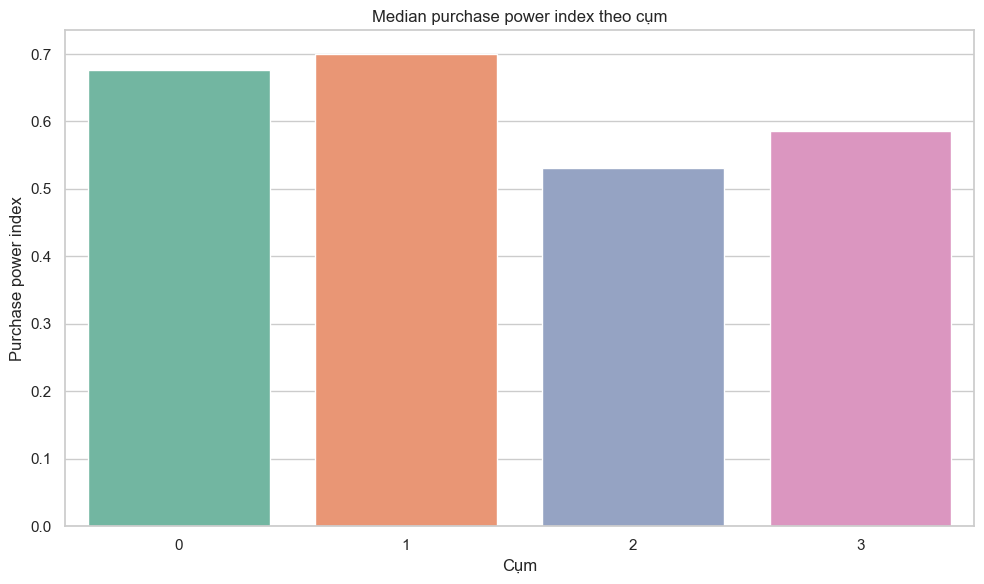

In [527]:


plot_df = (
    df.groupby('cluster_kmeans', as_index=False)['purchase_power_index']
      .median()
      .sort_values('purchase_power_index', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='cluster_kmeans', y='purchase_power_index', palette='Set2')
plt.title('Median purchase power index theo cụm')
plt.xlabel('Cụm')
plt.ylabel('Purchase power index')
plt.tight_layout()
plt.show()

In [528]:
other_summary = (
    df.groupby('cluster_kmeans')['device_Other']
      .agg(['mean', 'median', 'std', 'count'])
      .sort_values('mean', ascending=False)
)

print(other_summary)

                    mean    median       std  count
cluster_kmeans                                     
2               0.168744  0.159590  0.062101    322
3               0.111129  0.102749  0.033168     13
0               0.079511  0.061560  0.055078    788
1               0.070213  0.051430  0.054977   3966


C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\3654678836.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_other, x='cluster_kmeans', y='device_Other', palette='pastel')


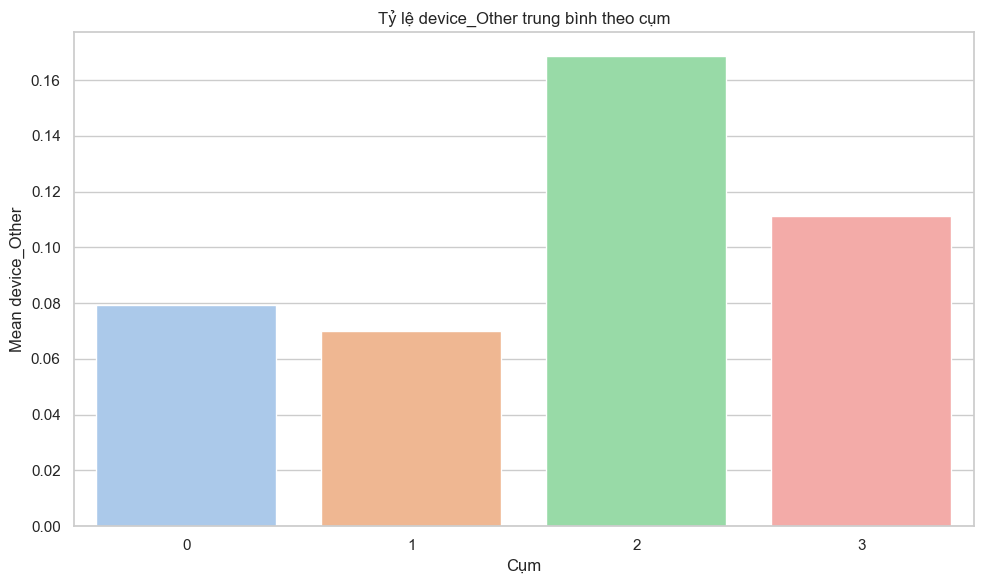

In [529]:
plot_other = (
    df.groupby('cluster_kmeans', as_index=False)['device_Other']
      .mean()
      .sort_values('device_Other', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_other, x='cluster_kmeans', y='device_Other', palette='pastel')
plt.title('Tỷ lệ device_Other trung bình theo cụm')
plt.xlabel('Cụm')
plt.ylabel('Mean device_Other')
plt.tight_layout()
plt.show()

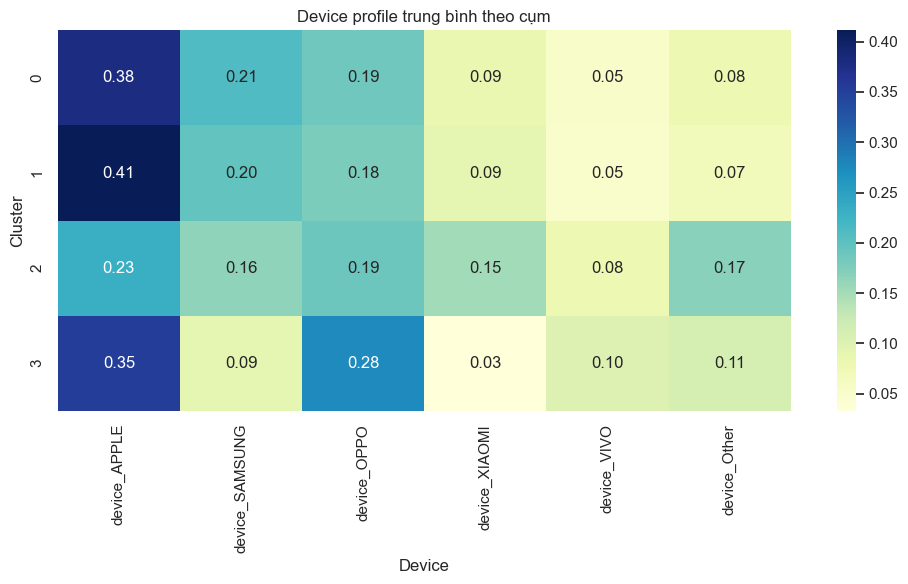

In [530]:
device_cols = [
    'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
    'device_XIAOMI', 'device_VIVO', 'device_Other'
]

cluster_device_profile = (
    df.groupby('cluster_kmeans')[device_cols]
      .mean()
)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_device_profile, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Device profile trung bình theo cụm')
plt.xlabel('Device')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [531]:
industry_cols = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']

industry_device_summary = []

for col in industry_cols:
    sub = df[df[col] == 1]
    industry_device_summary.append({
        'industry': col,
        'n': len(sub),
        'purchase_power_mean': sub['purchase_power_index'].mean(),
        'purchase_power_median': sub['purchase_power_index'].median(),
        'apple_mean': sub['device_APPLE'].mean(),
        'samsung_mean': sub['device_SAMSUNG'].mean(),
        'value_segment_mean': sub['device_value_segment'].mean(),
        'other_mean': sub['device_Other'].mean()
    })

industry_device_summary = pd.DataFrame(industry_device_summary)
industry_device_summary = industry_device_summary.sort_values('purchase_power_median', ascending=False)

print(industry_device_summary)

        industry     n  purchase_power_mean  purchase_power_median  \
1      Education   192             0.757619               0.757341   
0         Beauty  1448             0.694887               0.696255   
3           Food  1114             0.689528               0.695947   
4         Sports   118             0.666689               0.678582   
2  Entertainment  2698             0.666725               0.677959   

   apple_mean  samsung_mean  value_segment_mean  other_mean  
1    0.506189      0.189542            0.249491    0.050415  
0    0.415507      0.199659            0.299130    0.079582  
3    0.397656      0.207031            0.315617    0.073361  
4    0.372356      0.208476            0.318880    0.089878  
2    0.374587      0.191668            0.347009    0.081151  


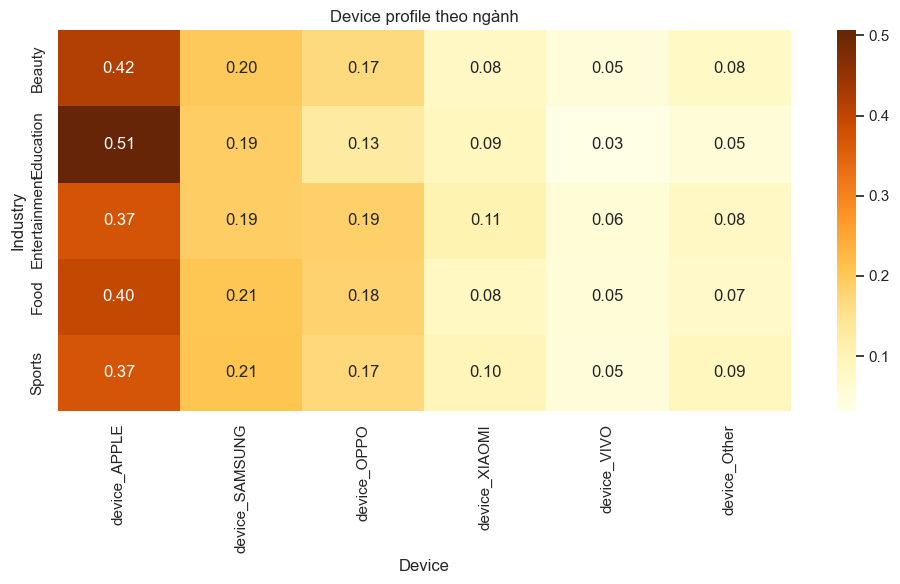

In [532]:
industry_profile = []

for col in industry_cols:
    sub = df[df[col] == 1]
    row = sub[device_cols].mean()
    row.name = col
    industry_profile.append(row)

industry_profile = pd.DataFrame(industry_profile)

plt.figure(figsize=(10, 6))
sns.heatmap(industry_profile, annot=True, fmt='.2f', cmap='YlOrBr')
plt.title('Device profile theo ngành')
plt.xlabel('Device')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\747648868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


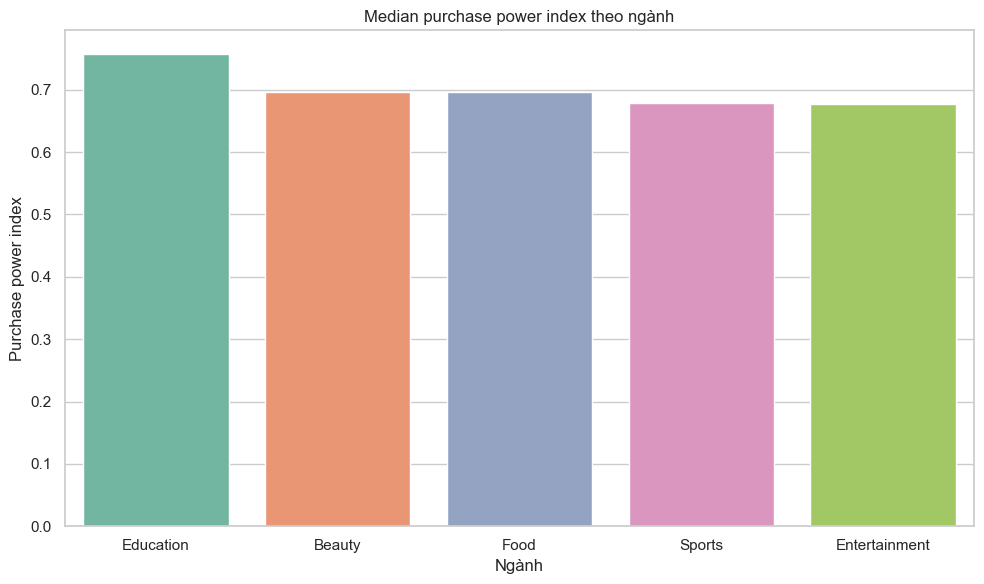

In [533]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=industry_device_summary,
    x='industry',
    y='purchase_power_median',
    palette='Set2'
)
plt.title('Median purchase power index theo ngành')
plt.xlabel('Ngành')
plt.ylabel('Purchase power index')
plt.tight_layout()
plt.show()

In [534]:
target_market_cols = [
    'country_US', 'country_JP', 'country_TW', 'country_KR',
    'country_MM', 'country_KH', 'country_TH', 'country_PH', 'country_ID'
]

In [535]:

country_cols = [
    'country_VN', 'country_US', 'country_JP', 'country_TW',
    'country_KR', 'country_MM', 'country_KH', 'country_TH',
    'country_PH', 'country_ID'
]

target_market_cols = [
    'country_US', 'country_JP', 'country_TW', 'country_KR',
    'country_MM', 'country_KH', 'country_TH', 'country_PH', 'country_ID'
]

# 1. share quốc tế mục tiêu
df['target_market_share'] = df[target_market_cols].sum(axis=1)

# 2. log follower để giảm lệch phải
df['log_followerCnt'] = np.log1p(df['followerCnt'])

# 3. entropy quốc gia: càng cao => audience càng phân tán đều
country_matrix = df[country_cols].fillna(0).copy()
row_sum = country_matrix.sum(axis=1)

# tránh chia 0
country_norm = country_matrix.div(row_sum.replace(0, np.nan), axis=0).fillna(0)

eps = 1e-12
df['country_entropy'] = -(
    country_norm * np.log(country_norm + eps)
).sum(axis=1) / np.log(len(country_cols))

In [536]:
cluster_geo = (
    df.groupby('cluster_kmeans')
      .agg(
          n=('handleName', 'count'),
          follower_median=('followerCnt', 'median'),
          follower_mean=('followerCnt', 'mean'),
          log_follower_median=('log_followerCnt', 'median'),
          vn_share_mean=('country_VN', 'mean'),
          vn_share_median=('country_VN', 'median'),
          target_market_share_mean=('target_market_share', 'mean'),
          target_market_share_median=('target_market_share', 'median'),
          entropy_mean=('country_entropy', 'mean'),
          entropy_median=('country_entropy', 'median')
      )
      .reset_index()
)

print(cluster_geo.sort_values('target_market_share_mean', ascending=False))

   cluster_kmeans     n  follower_median  follower_mean  log_follower_median  \
3               3    13          97263.0  286518.846154            11.485184   
2               2   322         238740.5  472682.633540            12.383118   
1               1  3966         150237.0  360449.642461            11.919976   
0               0   788         231061.5  623794.414975            12.350443   

   vn_share_mean  vn_share_median  target_market_share_mean  \
3       0.240529         0.251862                  0.710597   
2       0.356677         0.324367                  0.345195   
1       0.839043         0.937652                  0.060394   
0       0.839392         0.928818                  0.058546   

   target_market_share_median  entropy_mean  entropy_median  
3                    0.721889      0.302230        0.341348  
2                    0.337262      0.509206        0.533662  
1                    0.029654      0.123498        0.075356  
0                    0.028685      

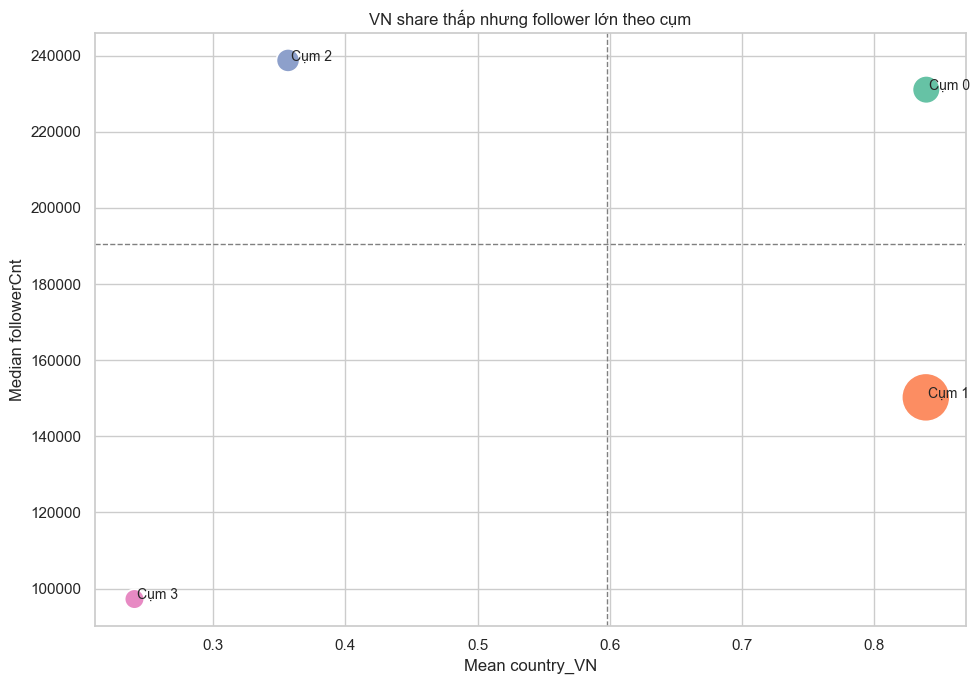

In [537]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=cluster_geo,
    x='vn_share_mean',
    y='follower_median',
    size='n',
    sizes=(200, 1200),
    hue='cluster_kmeans',
    palette='Set2',
    legend=False
)

# đường median để chia 4 quadrant
x_cut = cluster_geo['vn_share_mean'].median()
y_cut = cluster_geo['follower_median'].median()

plt.axvline(x_cut, color='gray', linestyle='--', linewidth=1)
plt.axhline(y_cut, color='gray', linestyle='--', linewidth=1)

for _, row in cluster_geo.iterrows():
    plt.text(
        row['vn_share_mean'] + 0.002,
        row['follower_median'],
        f"Cụm {int(row['cluster_kmeans'])}",
        fontsize=10
    )

plt.title('VN share thấp nhưng follower lớn theo cụm')
plt.xlabel('Mean country_VN')
plt.ylabel('Median followerCnt')
plt.tight_layout()
plt.show()

In [538]:
tmp = cluster_geo.copy()

tmp['follower_score'] = (
    (np.log1p(tmp['follower_median']) - np.log1p(tmp['follower_median']).mean()) /
    np.log1p(tmp['follower_median']).std()
)

tmp['low_vn_score'] = (
    (tmp['vn_share_mean'].mean() - tmp['vn_share_mean']) /
    tmp['vn_share_mean'].std()
)

tmp['low_vn_high_follow_score'] = tmp['follower_score'] + tmp['low_vn_score']

print(
    tmp.sort_values('low_vn_high_follow_score', ascending=False)[
        ['cluster_kmeans', 'follower_median', 'vn_share_mean', 'low_vn_high_follow_score']
    ]
)

   cluster_kmeans  follower_median  vn_share_mean  low_vn_high_follow_score
2               2         238740.5       0.356677                  1.496440
0               0         231061.5       0.839392                 -0.109893
3               3          97263.0       0.240529                 -0.259578
1               1         150237.0       0.839043                 -1.126970


C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\3583563793.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


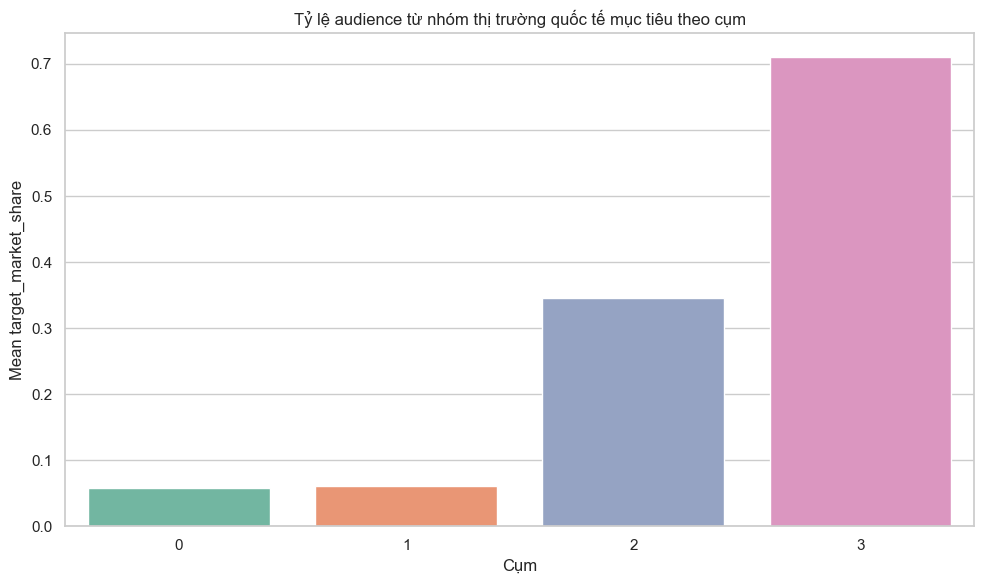

In [539]:
plot_intl = (
    cluster_geo[['cluster_kmeans', 'target_market_share_mean']]
    .sort_values('target_market_share_mean', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_intl,
    x='cluster_kmeans',
    y='target_market_share_mean',
    palette='Set2'
)

plt.title('Tỷ lệ audience từ nhóm thị trường quốc tế mục tiêu theo cụm')
plt.xlabel('Cụm')
plt.ylabel('Mean target_market_share')
plt.tight_layout()
plt.show()

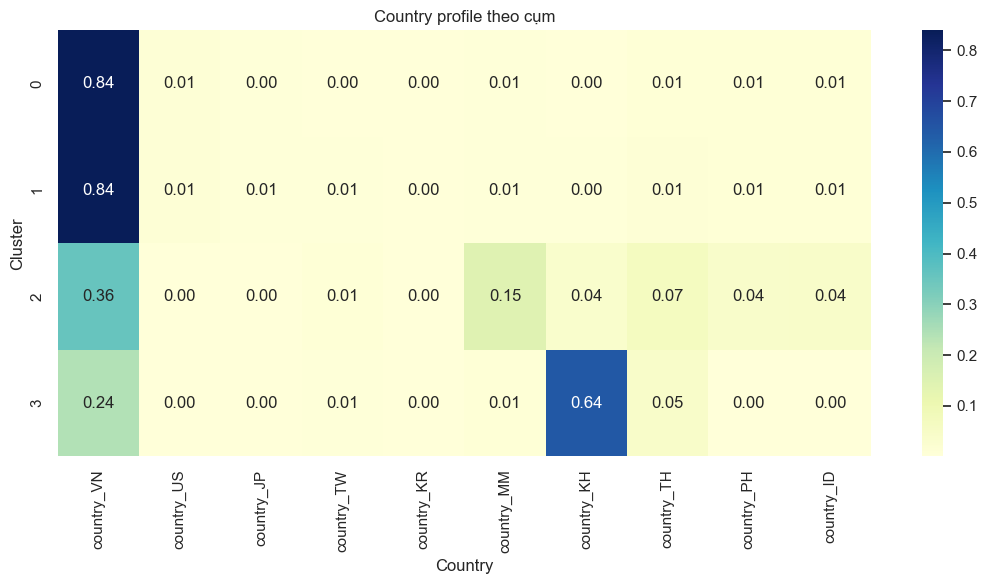

In [540]:
cluster_country_profile = (
    df.groupby('cluster_kmeans')[country_cols]
      .mean()
)

plt.figure(figsize=(11, 6))
sns.heatmap(
    cluster_country_profile,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Country profile theo cụm')
plt.xlabel('Country')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\1267634829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


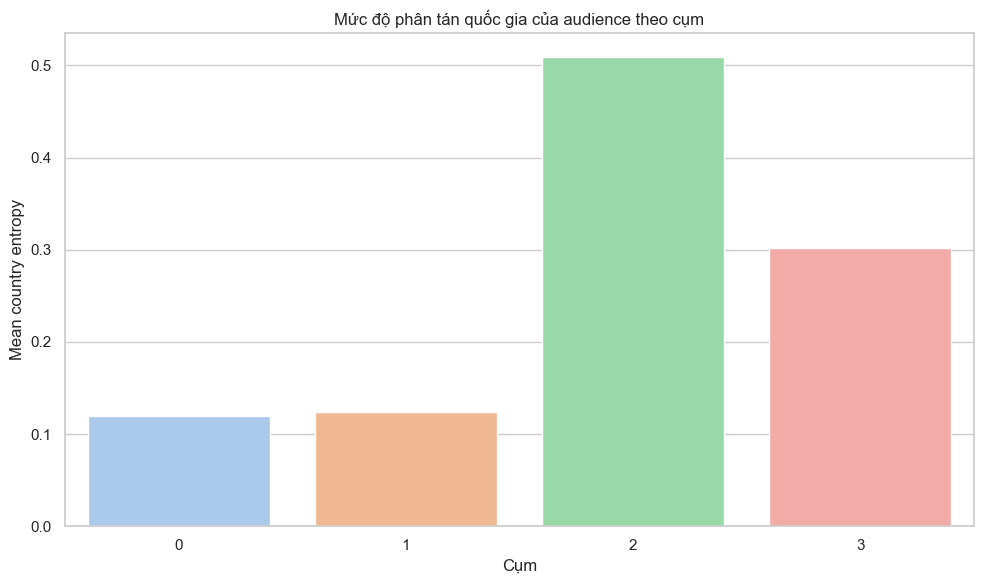

In [541]:
plot_entropy = (
    cluster_geo[['cluster_kmeans', 'entropy_mean']]
    .sort_values('entropy_mean', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_entropy,
    x='cluster_kmeans',
    y='entropy_mean',
    palette='pastel'
)

plt.title('Mức độ phân tán quốc gia của audience theo cụm')
plt.xlabel('Cụm')
plt.ylabel('Mean country entropy')
plt.tight_layout()
plt.show()

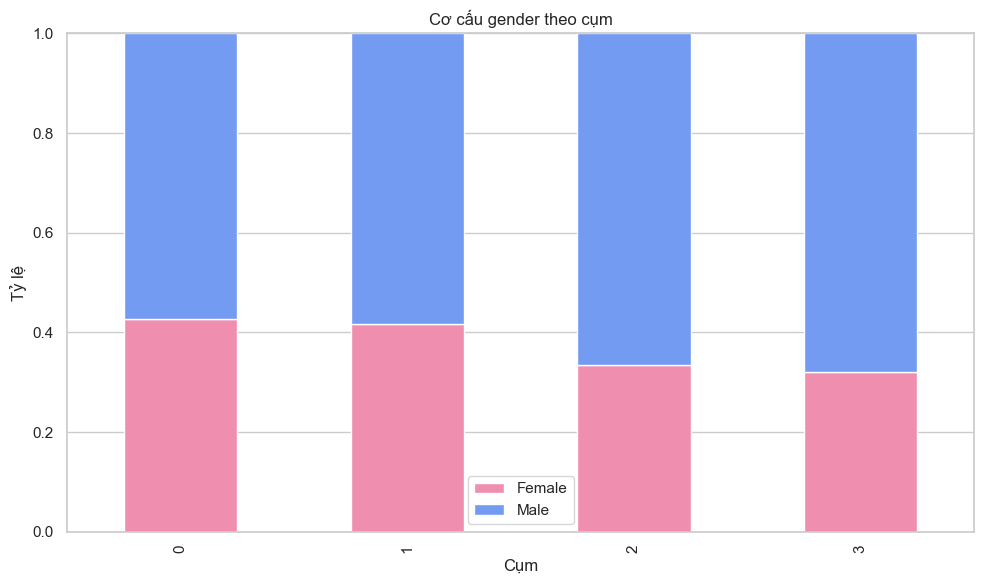

In [542]:
gender_cluster = (
    df.groupby('cluster_kmeans')[['gender_Female', 'gender_Male']]
      .mean()
)

gender_cluster.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=["#f08eb0", "#729bf1"]
)

plt.title('Cơ cấu gender theo cụm')
plt.xlabel('Cụm')
plt.ylabel('Tỷ lệ')
plt.ylim(0, 1)
plt.legend(['Female', 'Male'])
plt.tight_layout()
plt.show()


========== CLUSTER 0 ==========
gender_segment
Male-skewed      417
Female-skewed    193
Balanced         178
Name: count, dtype: int64


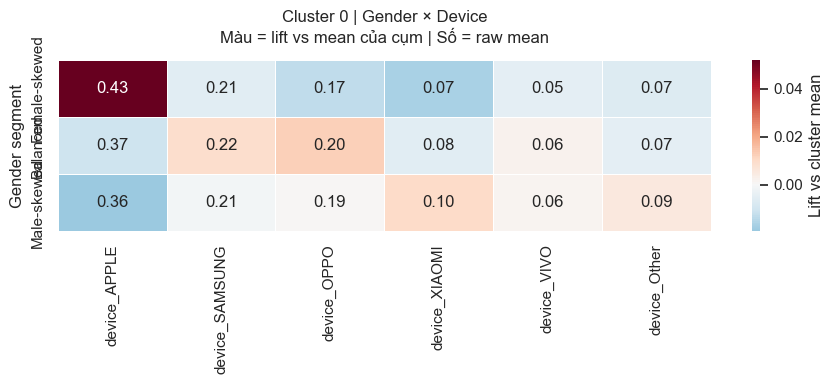

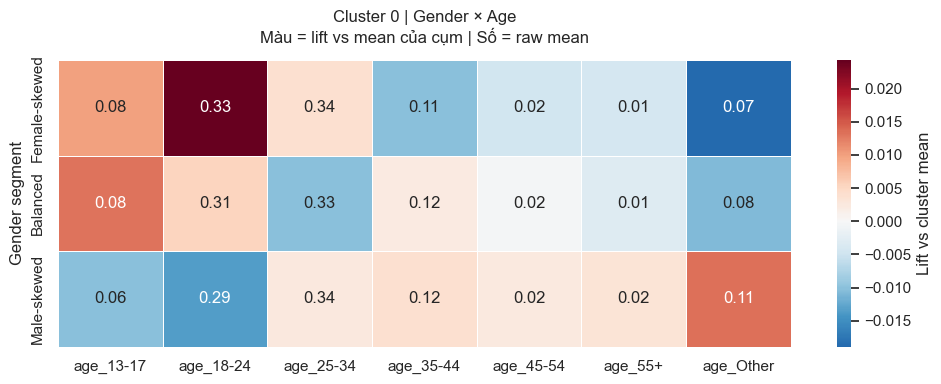

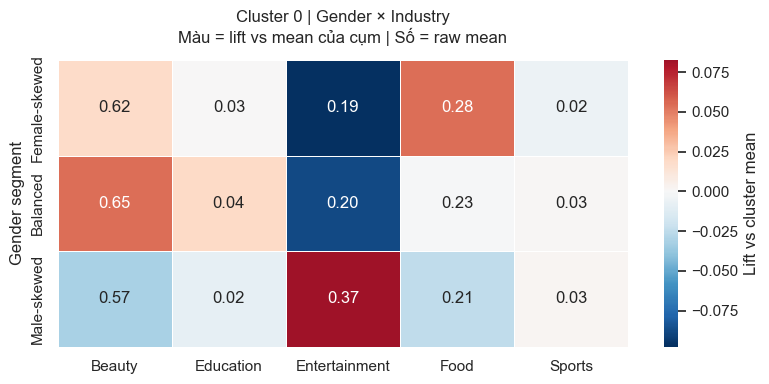


========== CLUSTER 1 ==========
gender_segment
Male-skewed      2184
Female-skewed    1044
Balanced          738
Name: count, dtype: int64


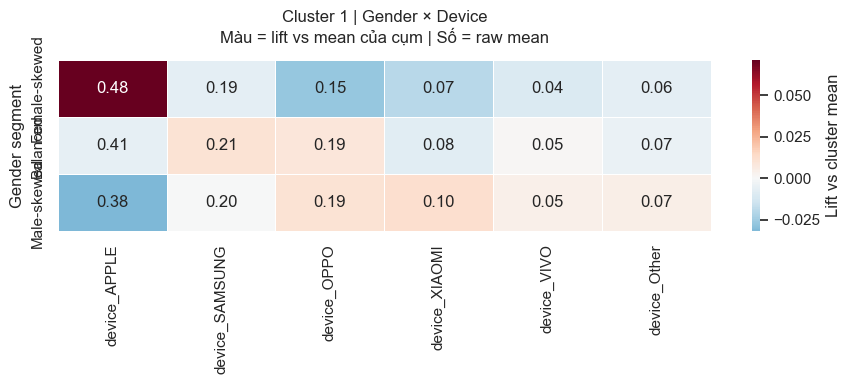

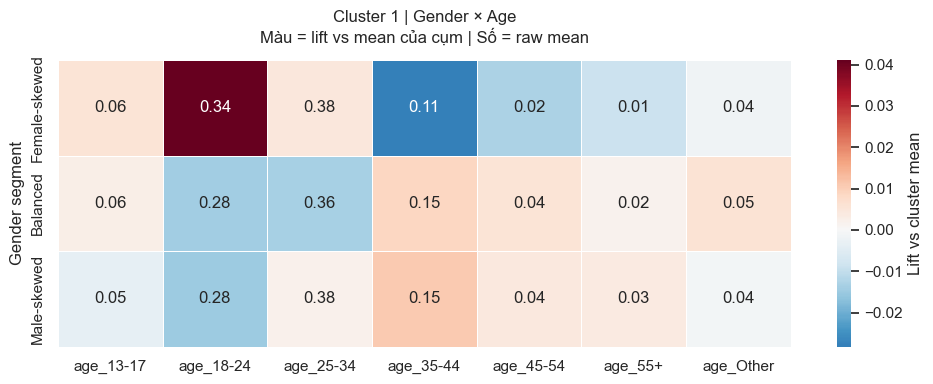

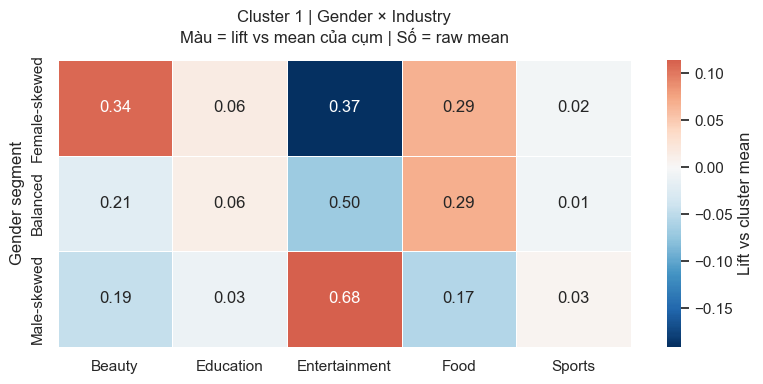


========== CLUSTER 2 ==========
gender_segment
Male-skewed      224
Balanced          50
Female-skewed     48
Name: count, dtype: int64


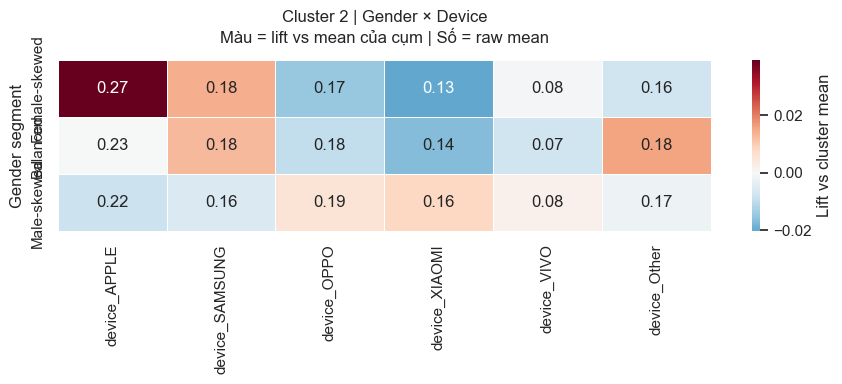

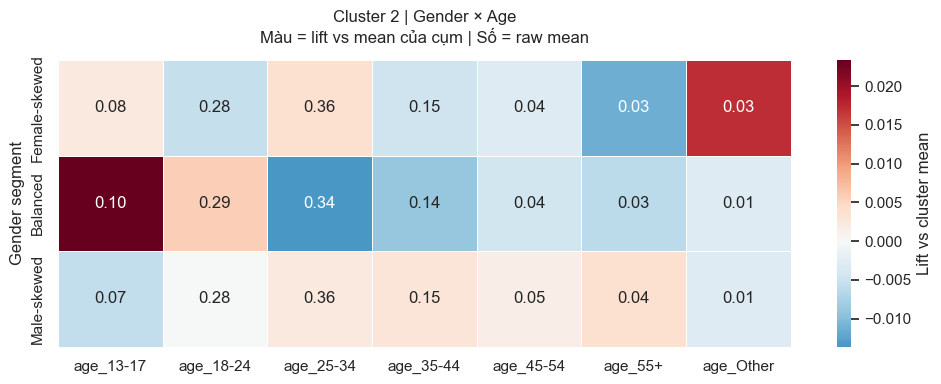

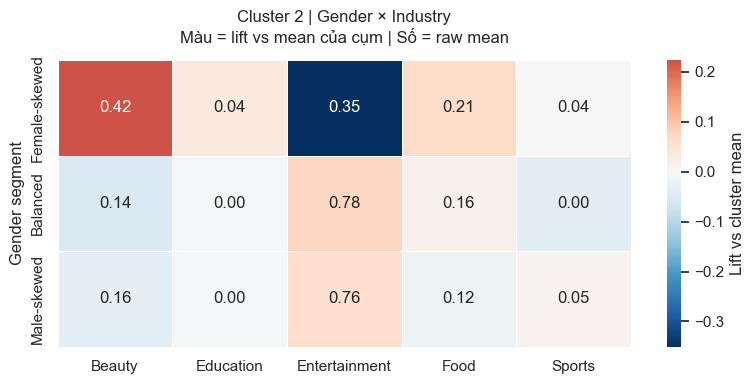


========== CLUSTER 3 ==========
gender_segment
Male-skewed      10
Balanced          2
Female-skewed     1
Name: count, dtype: int64


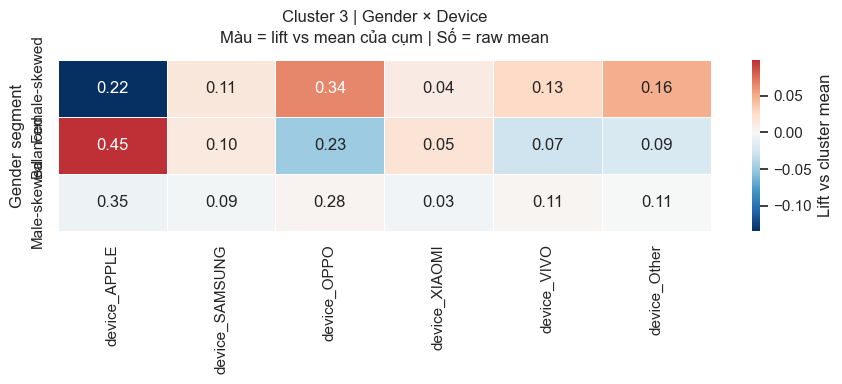

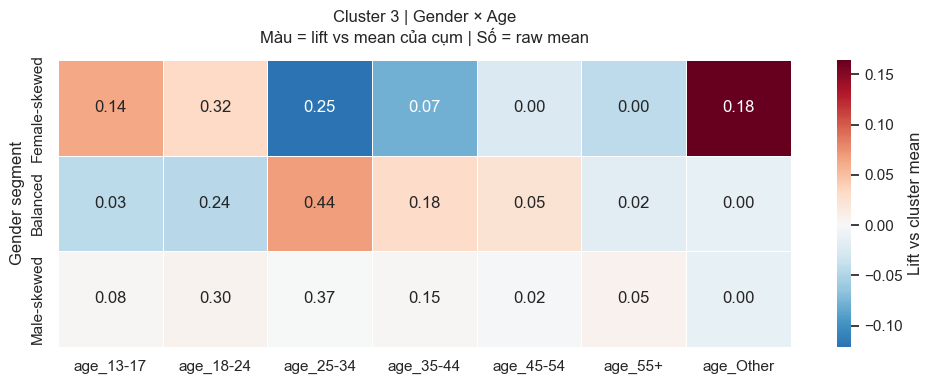

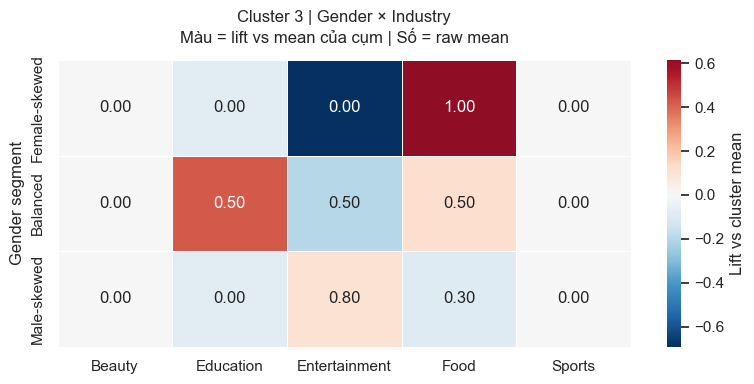

In [543]:
import os


# =========================
# CONFIG
# =========================
cluster_col = 'cluster_kmeans'
save_fig = False
output_dir = 'cluster_gender_cross_plots'
gender_threshold = 0.55

if save_fig:
    os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style='white', font_scale=1.0)

device_cols = [
    'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
    'device_XIAOMI', 'device_VIVO', 'device_Other'
]

age_cols = [
    'age_13-17', 'age_18-24', 'age_25-34',
    'age_35-44', 'age_45-54', 'age_55+', 'age_Other'
]

industry_cols = [
    'Beauty', 'Education', 'Entertainment', 'Food', 'Sports'
]


# =========================
# 1. TẠO NHÓM GENDER
# =========================
def add_gender_segment(data: pd.DataFrame, threshold: float = 0.55) -> pd.DataFrame:
    df = data.copy()

    df['gender_segment'] = np.select(
        [
            df['gender_Female'] >= threshold,
            df['gender_Male'] >= threshold
        ],
        [
            'Female-skewed',
            'Male-skewed'
        ],
        default='Balanced'
    )

    return df


# =========================
# 2. HÀM TẠO BẢNG RAW + LIFT
# =========================
def make_raw_and_lift_tables(sub_df: pd.DataFrame, cols: list, order: list):
    raw = (
        sub_df.groupby('gender_segment')[cols]
        .mean()
        .reindex(order)
    )

    # lift so với mean của chính cụm
    lift = raw - sub_df[cols].mean()

    return raw, lift


# =========================
# 3. HÀM VẼ HEATMAP
# =========================
def plot_heatmap(raw: pd.DataFrame,
                 lift: pd.DataFrame,
                 title: str,
                 figsize=(10, 4),
                 cmap='RdBu_r',
                 save_path=None):
    plt.figure(figsize=figsize)

    sns.heatmap(
        lift,
        annot=raw,
        fmt='.2f',
        cmap=cmap,
        center=0,
        linewidths=0.5,
        cbar_kws={'label': 'Lift vs cluster mean'}
    )

    plt.title(title + '\nMàu = lift vs mean của cụm | Số = raw mean', pad=12)
    plt.xlabel('')
    plt.ylabel('Gender segment')
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')

    plt.show()


# =========================
# 4. HÀM PHÂN TÍCH 1 CỤM
# =========================
def analyze_one_cluster(sub_df: pd.DataFrame, cluster_id, save_fig=False, output_dir=None):
    # thứ tự hiển thị cố định
    full_order = ['Female-skewed', 'Balanced', 'Male-skewed']
    order = [x for x in full_order if x in sub_df['gender_segment'].unique()]

    if len(order) == 0:
        print(f'Cluster {cluster_id}: không có dữ liệu gender_segment hợp lệ.')
        return

    # ===== Gender × Device =====
    raw_device, lift_device = make_raw_and_lift_tables(sub_df, device_cols, order)
    plot_heatmap(
        raw=raw_device,
        lift=lift_device,
        title=f'Cluster {cluster_id} | Gender × Device',
        figsize=(9, 4),
        cmap='RdBu_r',
        save_path=os.path.join(output_dir, f'cluster_{cluster_id}_gender_device.png') if save_fig else None
    )

    # ===== Gender × Age =====
    raw_age, lift_age = make_raw_and_lift_tables(sub_df, age_cols, order)
    plot_heatmap(
        raw=raw_age,
        lift=lift_age,
        title=f'Cluster {cluster_id} | Gender × Age',
        figsize=(10, 4),
        cmap='RdBu_r',
        save_path=os.path.join(output_dir, f'cluster_{cluster_id}_gender_age.png') if save_fig else None
    )

    # ===== Gender × Industry =====
    raw_industry, lift_industry = make_raw_and_lift_tables(sub_df, industry_cols, order)
    plot_heatmap(
        raw=raw_industry,
        lift=lift_industry,
        title=f'Cluster {cluster_id} | Gender × Industry',
        figsize=(8, 4),
        cmap='RdBu_r',
        save_path=os.path.join(output_dir, f'cluster_{cluster_id}_gender_industry.png') if save_fig else None
    )

    return {
        'raw_device': raw_device,
        'lift_device': lift_device,
        'raw_age': raw_age,
        'lift_age': lift_age,
        'raw_industry': raw_industry,
        'lift_industry': lift_industry
    }


# =========================
# 5. CHẠY TOÀN BỘ CỤM
# =========================
df_plot = add_gender_segment(df, threshold=gender_threshold)

all_cluster_results = {}

clusters = sorted(df_plot[cluster_col].dropna().unique())

for cluster_id in clusters:
    sub = df_plot[df_plot[cluster_col] == cluster_id].copy()

    print(f'\n========== CLUSTER {cluster_id} ==========')
    print(sub['gender_segment'].value_counts(dropna=False))

    result = analyze_one_cluster(
        sub_df=sub,
        cluster_id=cluster_id,
        save_fig=save_fig,
        output_dir=output_dir
    )

    all_cluster_results[cluster_id] = result

In [544]:
def female_minus_male_diff(result_dict, table_name='raw_device'):
    tbl = result_dict[table_name].copy()

    if ('Female-skewed' not in tbl.index) or ('Male-skewed' not in tbl.index):
        return None

    diff = tbl.loc['Female-skewed'] - tbl.loc['Male-skewed']
    return diff.sort_values(ascending=False)


# ví dụ:
for cluster_id, res in all_cluster_results.items():
    print(f'\n===== CLUSTER {cluster_id} | DEVICE DIFF (Female-skewed - Male-skewed) =====')
    diff_device = female_minus_male_diff(res, 'raw_device')
    print(diff_device)

    print(f'\n===== CLUSTER {cluster_id} | AGE DIFF (Female-skewed - Male-skewed) =====')
    diff_age = female_minus_male_diff(res, 'raw_age')
    print(diff_age)

    print(f'\n===== CLUSTER {cluster_id} | INDUSTRY DIFF (Female-skewed - Male-skewed) =====')
    diff_industry = female_minus_male_diff(res, 'raw_industry')
    print(diff_industry)


===== CLUSTER 0 | DEVICE DIFF (Female-skewed - Male-skewed) =====
device_APPLE      0.071672
device_SAMSUNG   -0.004399
device_VIVO      -0.006468
device_Other     -0.012621
device_OPPO      -0.013982
device_XIAOMI    -0.026696
dtype: float64

===== CLUSTER 0 | AGE DIFF (Female-skewed - Male-skewed) =====
age_18-24    0.037796
age_13-17    0.020126
age_25-34    0.001309
age_45-54   -0.006913
age_55+     -0.007699
age_35-44   -0.014065
age_Other   -0.032203
dtype: float64

===== CLUSTER 0 | INDUSTRY DIFF (Female-skewed - Male-skewed) =====
Food             0.078739
Beauty           0.050633
Education        0.009120
Sports          -0.008052
Entertainment   -0.180378
dtype: float64

===== CLUSTER 1 | DEVICE DIFF (Female-skewed - Male-skewed) =====
device_APPLE      0.103288
device_SAMSUNG   -0.006647
device_Other     -0.011392
device_VIVO      -0.014382
device_XIAOMI    -0.031082
device_OPPO      -0.037240
dtype: float64

===== CLUSTER 1 | AGE DIFF (Female-skewed - Male-skewed) =====
a

In [545]:

industry_cols = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']
cluster_col = 'cluster_kmeans'

performance_cols = [
    'followersGrowthRate',
    'avgSixSecondsViewsRate',
    'videoCompleteRate',
    'engagementRate',
    'medianViews'
]

base_cols = ['handleName', cluster_col, 'commercialScore', 'broadcastingScore'] + performance_cols

industry_long = (
    df[base_cols + industry_cols]
    .melt(
        id_vars=base_cols,
        value_vars=industry_cols,
        var_name='industry',
        value_name='flag'
    )
)

industry_long = industry_long[industry_long['flag'] == 1].drop(columns='flag').copy()

print(industry_long.head())

        handleName  cluster_kmeans  commercialScore  broadcastingScore  \
2       n.huyen2k4               0             84.0               93.1   
6      msquynhthie               1             60.0               98.6   
13    iuoilaiu_000               1             60.0               88.2   
14  theforumcenter               0             96.0               98.0   
26        lykio.98               0             98.4               94.4   

    followersGrowthRate  avgSixSecondsViewsRate  videoCompleteRate  \
2             -0.003541                  0.3278           0.117057   
6             -0.004645                  0.3835           0.118231   
13            -0.003181                  0.5965           0.071661   
14             0.021563                  0.3234           0.184484   
26            -0.001241                  0.3239           0.195228   

    engagementRate  medianViews industry  
2           0.1279     128875.0   Beauty  
6           0.0550     643734.0   Beauty  
13   

In [546]:
industry_cluster_count = pd.crosstab(
    industry_long['industry'],
    industry_long[cluster_col]
)

industry_cluster_share = industry_cluster_count.div(
    industry_cluster_count.sum(axis=1),
    axis=0
)

print(industry_cluster_share)

cluster_kmeans         0         1         2         3
industry                                              
Beauty          0.325276  0.631906  0.042818  0.000000
Education       0.104167  0.880208  0.010417  0.005208
Entertainment   0.083024  0.829503  0.084136  0.003336
Food            0.163375  0.790844  0.041293  0.004488
Sports          0.177966  0.711864  0.110169  0.000000


In [547]:
k = industry_cluster_share.shape[1]

industry_concentration = pd.DataFrame({
    'n': industry_cluster_count.sum(axis=1),
    'top1_share': industry_cluster_share.max(axis=1),
    'top2_share': industry_cluster_share.apply(lambda s: s.nlargest(min(2, len(s))).sum(), axis=1),
    'entropy_norm': industry_cluster_share.apply(
        lambda s: -(s[s > 0] * np.log(s[s > 0])).sum() / np.log(k),
        axis=1
    ),
    'hhi': (industry_cluster_share ** 2).sum(axis=1)
}).sort_values('hhi', ascending=False)

print(industry_concentration)

                  n  top1_share  top2_share  entropy_norm       hhi
industry                                                           
Education       192    0.880208    0.984375      0.305015  0.785753
Entertainment  2698    0.829503    0.913640      0.424846  0.702059
Food           1114    0.790844    0.954219      0.459809  0.653851
Sports          118    0.711864    0.889831      0.571410  0.550560
Beauty         1448    0.631906    0.957182      0.570063  0.506943


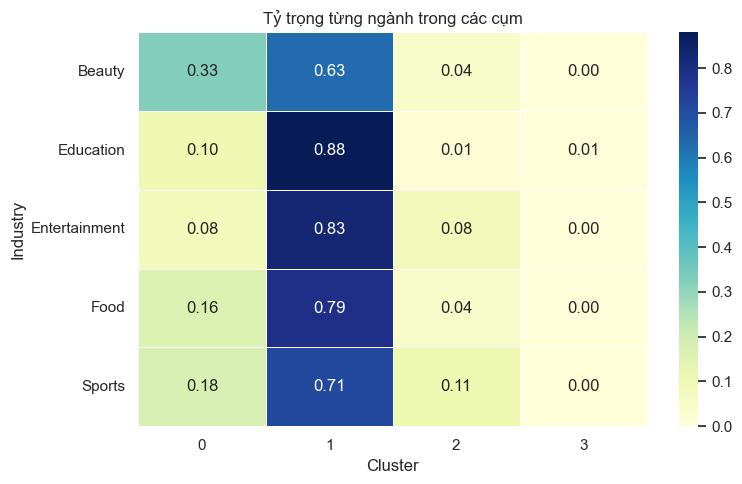

In [548]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    industry_cluster_share,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title('Tỷ trọng từng ngành trong các cụm')
plt.xlabel('Cluster')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

In [549]:
perf = industry_long[[cluster_col, 'industry'] + performance_cols].dropna().copy()

# z-score từng metric
for c in performance_cols:
    perf[f'{c}_z'] = (perf[c] - perf[c].mean()) / perf[c].std(ddof=0)

z_cols = [f'{c}_z' for c in performance_cols]
perf['performance_index'] = perf[z_cols].mean(axis=1)

In [550]:
var_table = (
    perf.groupby([cluster_col, 'industry'])
        .agg(
            n=('performance_index', 'size'),
            perf_var=('performance_index', 'var'),
            perf_std=('performance_index', 'std'),
            perf_mean=('performance_index', 'mean')
        )
        .reset_index()
)

# lọc nhóm quá ít creator để tránh variance nhiễu
min_n = 20
var_table_filtered = var_table[var_table['n'] >= min_n].copy()

print(var_table_filtered.sort_values('perf_var', ascending=False).head(20))

    cluster_kmeans       industry     n  perf_var  perf_std  perf_mean
12               2  Entertainment   227  0.711083  0.843258   0.227499
4                0         Sports    21  0.374893  0.612285  -0.238347
13               2           Food    46  0.312117  0.558675  -0.039950
10               2         Beauty    62  0.309517  0.556342  -0.226018
5                1         Beauty   915  0.255159  0.505132  -0.194480
7                1  Entertainment  2238  0.238415  0.488277   0.206927
0                0         Beauty   471  0.225619  0.474994  -0.396752
8                1           Food   881  0.210307  0.458593  -0.100931
2                0  Entertainment   224  0.205875  0.453734   0.108271
9                1         Sports    84  0.186006  0.431284  -0.044233
3                0           Food   182  0.166529  0.408080  -0.332200
6                1      Education   169  0.142732  0.377799  -0.000368
1                0      Education    20  0.088752  0.297913  -0.245484


In [551]:
top_var_within_cluster = (
    var_table_filtered
    .sort_values([cluster_col, 'perf_var'], ascending=[True, False])
    .groupby(cluster_col)
    .head(1)
)

print(top_var_within_cluster[[cluster_col, 'industry', 'n', 'perf_var', 'perf_std']])

    cluster_kmeans       industry    n  perf_var  perf_std
4                0         Sports   21  0.374893  0.612285
5                1         Beauty  915  0.255159  0.505132
12               2  Entertainment  227  0.711083  0.843258


In [552]:
industry_var_summary = (
    var_table_filtered.groupby('industry')
    .apply(lambda g: pd.Series({
        'weighted_perf_var': np.average(g['perf_var'], weights=g['n']),
        'weighted_perf_std': np.average(g['perf_std'], weights=g['n']),
        'n_total': g['n'].sum()
    }))
    .sort_values('weighted_perf_var', ascending=False)
)

print(industry_var_summary)

               weighted_perf_var  weighted_perf_std  n_total
industry                                                    
Entertainment           0.275606           0.515367   2689.0
Beauty                  0.247878           0.497522   1448.0
Sports                  0.223783           0.467484    105.0
Food                    0.207346           0.454454   1109.0
Education               0.137020           0.369345    189.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\1146700141.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


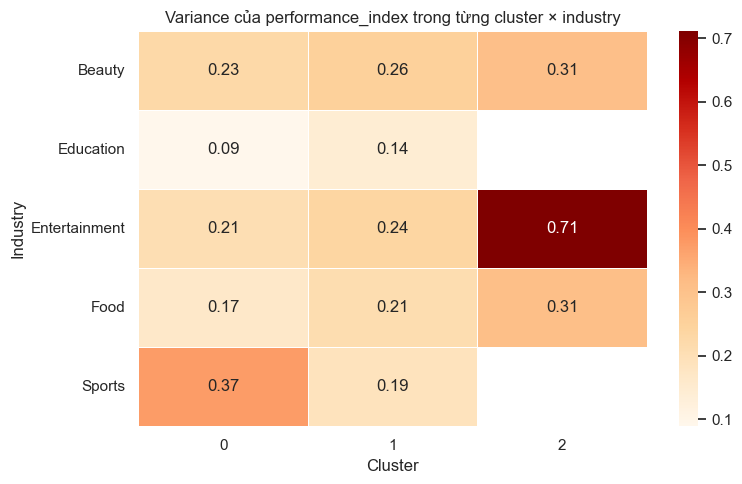

In [553]:
pivot_var = var_table_filtered.pivot(
    index='industry',
    columns=cluster_col,
    values='perf_var'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_var,
    annot=True,
    fmt='.2f',
    cmap='OrRd',
    linewidths=0.5
)
plt.title('Variance của performance_index trong từng cluster × industry')
plt.xlabel('Cluster')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

In [554]:
sports_dist = industry_cluster_share.loc['Sports']
edu_dist = industry_cluster_share.loc['Education']

compare_se = pd.DataFrame({
    'Sports': sports_dist,
    'Education': edu_dist
})

print(compare_se)

                  Sports  Education
cluster_kmeans                     
0               0.177966   0.104167
1               0.711864   0.880208
2               0.110169   0.010417
3               0.000000   0.005208


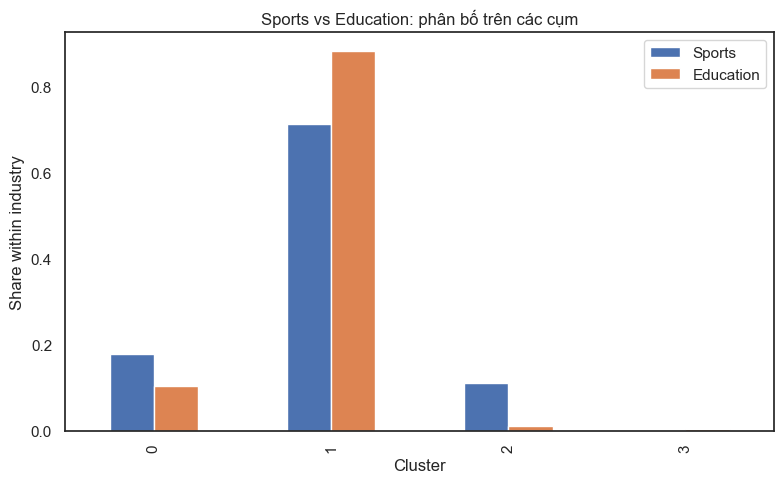

In [555]:
compare_se.plot(kind='bar', figsize=(8, 5))
plt.title('Sports vs Education: phân bố trên các cụm')
plt.xlabel('Cluster')
plt.ylabel('Share within industry')
plt.tight_layout()
plt.show()

In [556]:
industry_score = (
    industry_long.groupby('industry')
    .agg(
        n=('industry', 'size'),
        commercial_mean=('commercialScore', 'mean'),
        broadcasting_mean=('broadcastingScore', 'mean')
    )
    .reset_index()
    .sort_values('commercial_mean', ascending=False)
)

print(industry_score)

        industry     n  commercial_mean  broadcasting_mean
0         Beauty  1448        70.117680          86.864848
4         Sports   118        65.484746          86.899153
3           Food  1114        64.952244          86.412029
2  Entertainment  2698        62.579689          88.591216
1      Education   192        62.220833          87.183854


C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\1444177891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


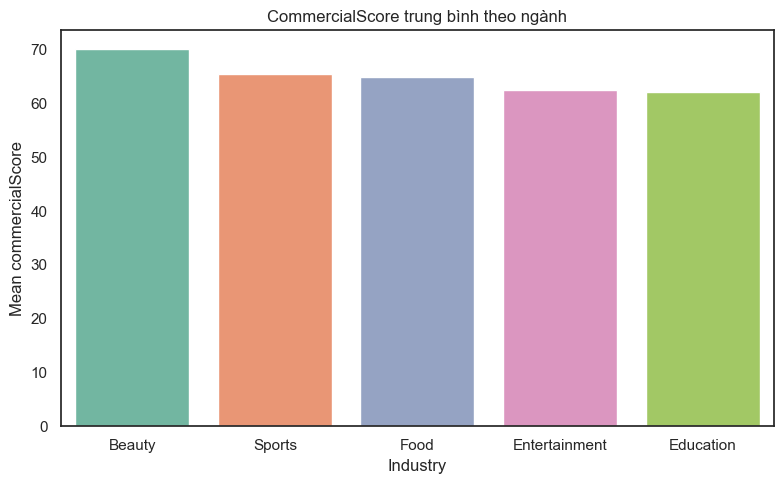

In [557]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=industry_score,
    x='industry',
    y='commercial_mean',
    palette='Set2'
)
plt.title('CommercialScore trung bình theo ngành')
plt.xlabel('Industry')
plt.ylabel('Mean commercialScore')
plt.tight_layout()
plt.show()

In [558]:
score_compare = industry_score.copy()

for c in ['broadcasting_mean', 'commercial_mean']:
    score_compare[f'{c}_z'] = (
        score_compare[c] - score_compare[c].mean()
    ) / score_compare[c].std(ddof=0)

score_compare['broadcast_advantage_z'] = (
    score_compare['broadcasting_mean_z'] - score_compare['commercial_mean_z']
)

print(
    score_compare.sort_values('broadcast_advantage_z', ascending=False)[
        ['industry', 'broadcasting_mean', 'commercial_mean', 'broadcast_advantage_z']
    ]
)

        industry  broadcasting_mean  commercial_mean  broadcast_advantage_z
2  Entertainment          88.591216        62.579689               2.767017
1      Education          87.183854        62.220833               0.999327
4         Sports          86.899153        65.484746              -0.538131
3           Food          86.412029        64.952244              -1.005592
0         Beauty          86.864848        70.117680              -2.222622


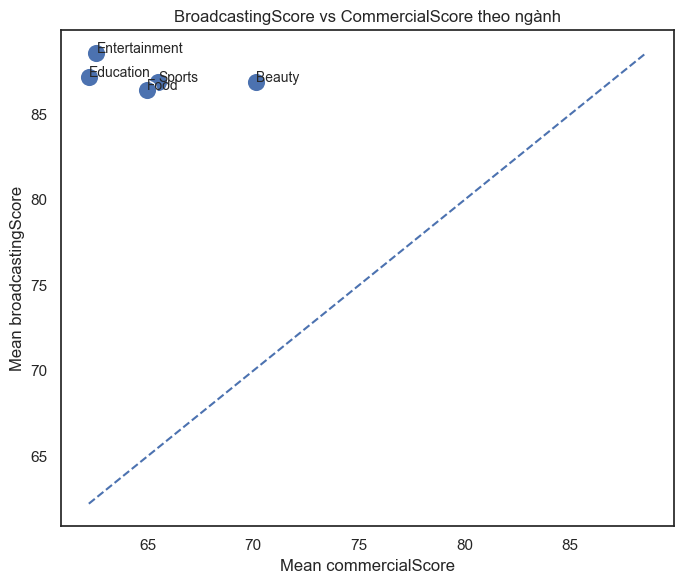

In [559]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=score_compare,
    x='commercial_mean',
    y='broadcasting_mean',
    s=180
)

for _, row in score_compare.iterrows():
    plt.text(
        row['commercial_mean'] + 0.005,
        row['broadcasting_mean'],
        row['industry'],
        fontsize=10
    )

# đường y = x
min_val = min(score_compare['commercial_mean'].min(), score_compare['broadcasting_mean'].min())
max_val = max(score_compare['commercial_mean'].max(), score_compare['broadcasting_mean'].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.title('BroadcastingScore vs CommercialScore theo ngành')
plt.xlabel('Mean commercialScore')
plt.ylabel('Mean broadcastingScore')
plt.tight_layout()
plt.show()

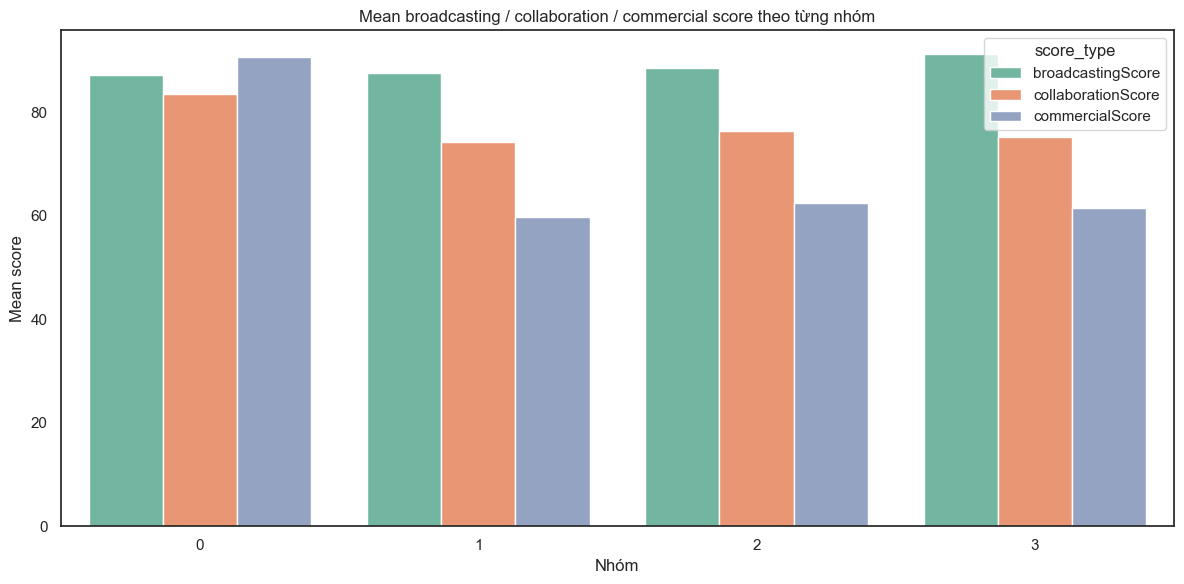

In [560]:

group_col = 'cluster_kmeans'   # đổi thành cột nhóm bạn muốn
score_cols = ['broadcastingScore', 'collaborationScore', 'commercialScore']

plot_df = (
    df[[group_col] + score_cols]
    .melt(id_vars=group_col, var_name='score_type', value_name='score')
)

summary_df = (
    plot_df.groupby([group_col, 'score_type'], as_index=False)['score']
    .mean()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=summary_df,
    x=group_col,
    y='score',
    hue='score_type',
    palette='Set2'
)

plt.title('Mean broadcasting / collaboration / commercial score theo từng nhóm')
plt.xlabel('Nhóm')
plt.ylabel('Mean score')
plt.tight_layout()
plt.show()

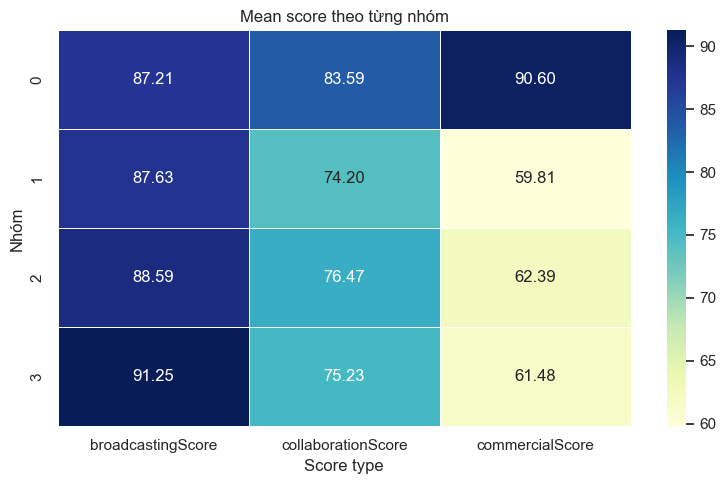

In [561]:
group_col = 'cluster_kmeans'

heatmap_df = (
    df.groupby(group_col)[['broadcastingScore', 'collaborationScore', 'commercialScore']]
    .mean()
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Mean score theo từng nhóm')
plt.xlabel('Score type')
plt.ylabel('Nhóm')
plt.tight_layout()
plt.show()

In [562]:

cluster_col = 'cluster_kmeans'
eps = 1e-9

# 15 video gần nhất so với baseline 30 ngày
df['recent_acceleration'] = (
    (df['median_view_recent'] - df['medianViews']) /
    (df['medianViews'] + eps)
)

# ratio trực tiếp, dễ đọc hơn nếu cần
df['recent_acceleration_ratio'] = (
    df['median_view_recent'] / (df['medianViews'] + eps)
)

# tỷ lệ bùng nổ
df['burst_ratio'] = df['max_view_recent'] / (df['median_view_recent'] + eps)

In [563]:
cluster_recent = (
    df.groupby(cluster_col)
      .agg(
          n=('handleName', 'count'),

          medianViews_median=('medianViews', 'median'),
          median_view_recent_median=('median_view_recent', 'median'),

          recent_acceleration_median=('recent_acceleration', 'median'),
          recent_acceleration_mean=('recent_acceleration', 'mean'),

          cov_view_recent_median=('cov_view_recent', 'median'),
          cov_view_recent_mean=('cov_view_recent', 'mean'),

          burstiness_recent_median=('burstiness_recent', 'median'),
          burstiness_recent_mean=('burstiness_recent', 'mean'),

          recency_days_recent_median=('recency_days_recent', 'median'),
          recency_days_recent_mean=('recency_days_recent', 'mean'),

          burst_ratio_median=('burst_ratio', 'median'),
          burst_ratio_mean=('burst_ratio', 'mean')
      )
      .reset_index()
)

print(cluster_recent.sort_values('recent_acceleration_median', ascending=False))

   cluster_kmeans     n  medianViews_median  median_view_recent_median  \
3               3    13             17322.0                    19262.0   
0               0   788             41724.5                    43961.0   
2               2   322             23255.0                    21904.0   
1               1  3966             36908.0                    36293.5   

   recent_acceleration_median  recent_acceleration_mean  \
3                    0.030914              1.392212e-02   
0                    0.002176              8.835506e-01   
2                   -0.004729              1.786768e-01   
1                   -0.017828              5.973777e+09   

   cov_view_recent_median  cov_view_recent_mean  burstiness_recent_median  \
3                1.319528              1.375052                 -0.036880   
0                1.194916              1.313369                 -0.030984   
2                1.234680              1.383030                 -0.004156   
1                1.235818

In [564]:
print("=== Tăng tốc mạnh nhất ===")
print(
    cluster_recent.sort_values('recent_acceleration_median', ascending=False)[
        [cluster_col, 'n', 'recent_acceleration_median', 'medianViews_median', 'median_view_recent_median']
    ]
)

print("\n=== Mất đà mạnh nhất ===")
print(
    cluster_recent.sort_values('recent_acceleration_median', ascending=True)[
        [cluster_col, 'n', 'recent_acceleration_median', 'medianViews_median', 'median_view_recent_median']
    ]
)

=== Tăng tốc mạnh nhất ===
   cluster_kmeans     n  recent_acceleration_median  medianViews_median  \
3               3    13                    0.030914             17322.0   
0               0   788                    0.002176             41724.5   
2               2   322                   -0.004729             23255.0   
1               1  3966                   -0.017828             36908.0   

   median_view_recent_median  
3                    19262.0  
0                    43961.0  
2                    21904.0  
1                    36293.5  

=== Mất đà mạnh nhất ===
   cluster_kmeans     n  recent_acceleration_median  medianViews_median  \
1               1  3966                   -0.017828             36908.0   
2               2   322                   -0.004729             23255.0   
0               0   788                    0.002176             41724.5   
3               3    13                    0.030914             17322.0   

   median_view_recent_median  
1        

In [565]:
print("=== CoV cao nhất ===")
print(
    cluster_recent.sort_values('cov_view_recent_median', ascending=False)[
        [cluster_col, 'n', 'cov_view_recent_median', 'cov_view_recent_mean']
    ]
)

=== CoV cao nhất ===
   cluster_kmeans     n  cov_view_recent_median  cov_view_recent_mean
3               3    13                1.319528              1.375052
1               1  3966                1.235818              1.333893
2               2   322                1.234680              1.383030
0               0   788                1.194916              1.313369


In [566]:
print("=== Burstiness cao nhất ===")
print(
    cluster_recent.sort_values('burstiness_recent_median', ascending=False)[
        [cluster_col, 'n', 'burstiness_recent_median', 'burstiness_recent_mean']
    ]
)

=== Burstiness cao nhất ===
   cluster_kmeans     n  burstiness_recent_median  burstiness_recent_mean
2               2   322                 -0.004156               -0.009987
0               0   788                 -0.030984               -0.038445
3               3    13                 -0.036880               -0.042886
1               1  3966                 -0.048970               -0.052345


In [567]:
print("=== Recency days cao nhất ===")
print(
    cluster_recent.sort_values('recency_days_recent_median', ascending=False)[
        [cluster_col, 'n', 'recency_days_recent_median', 'recency_days_recent_mean']
    ]
)

=== Recency days cao nhất ===
   cluster_kmeans     n  recency_days_recent_median  recency_days_recent_mean
0               0   788                    2.497708                  4.166663
1               1  3966                    2.496771                  6.685332
3               3    13                    2.492951                  7.475752
2               2   322                    2.392697                  6.494906


In [568]:
print("=== Burst ratio cao nhất ===")
print(
    cluster_recent.sort_values('burst_ratio_median', ascending=False)[
        [cluster_col, 'n', 'burst_ratio_median', 'burst_ratio_mean']
    ]
)

=== Burst ratio cao nhất ===
   cluster_kmeans     n  burst_ratio_median  burst_ratio_mean
3               3    13           10.240852         16.801990
2               2   322            8.962402         40.149828
1               1  3966            8.835728         21.318722
0               0   788            8.044468         20.994243


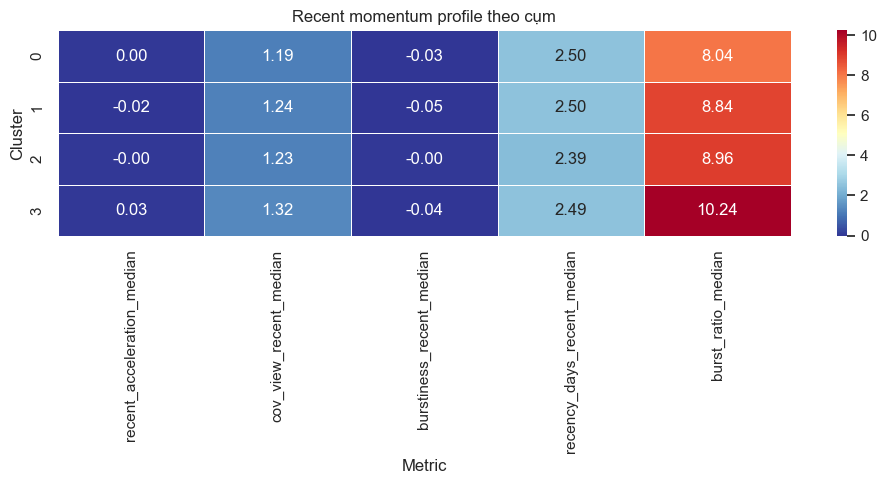

In [569]:
heatmap_cols = [
    'recent_acceleration_median',
    'cov_view_recent_median',
    'burstiness_recent_median',
    'recency_days_recent_median',
    'burst_ratio_median'
]

heatmap_df = cluster_recent.set_index(cluster_col)[heatmap_cols]

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    linewidths=0.5
)
plt.title('Recent momentum profile theo cụm')
plt.xlabel('Metric')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\483803435.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


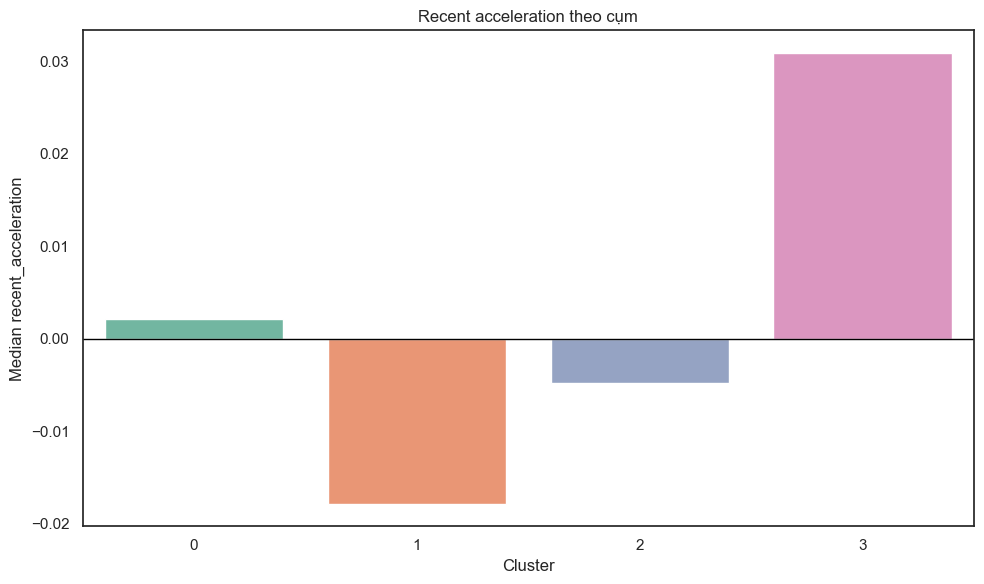

In [570]:
plot_acc = cluster_recent.sort_values('recent_acceleration_median', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_acc,
    x=cluster_col,
    y='recent_acceleration_median',
    palette='Set2'
)
plt.axhline(0, color='black', linewidth=1)
plt.title('Recent acceleration theo cụm')
plt.xlabel('Cluster')
plt.ylabel('Median recent_acceleration')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\3360803979.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


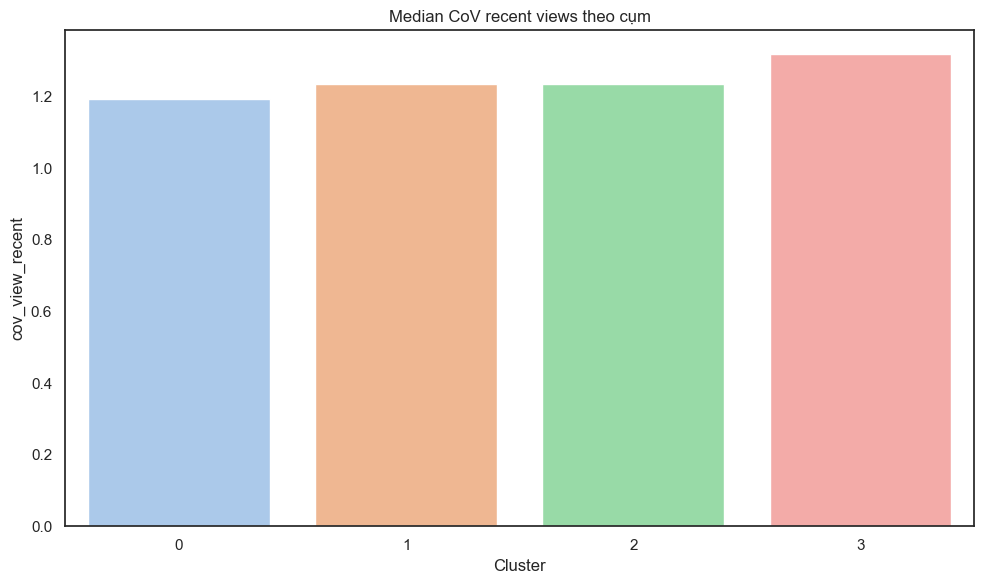

In [571]:
plot_cov = cluster_recent.sort_values('cov_view_recent_median', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_cov,
    x=cluster_col,
    y='cov_view_recent_median',
    palette='pastel'
)
plt.title('Median CoV recent views theo cụm')
plt.xlabel('Cluster')
plt.ylabel('cov_view_recent')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\1789047035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


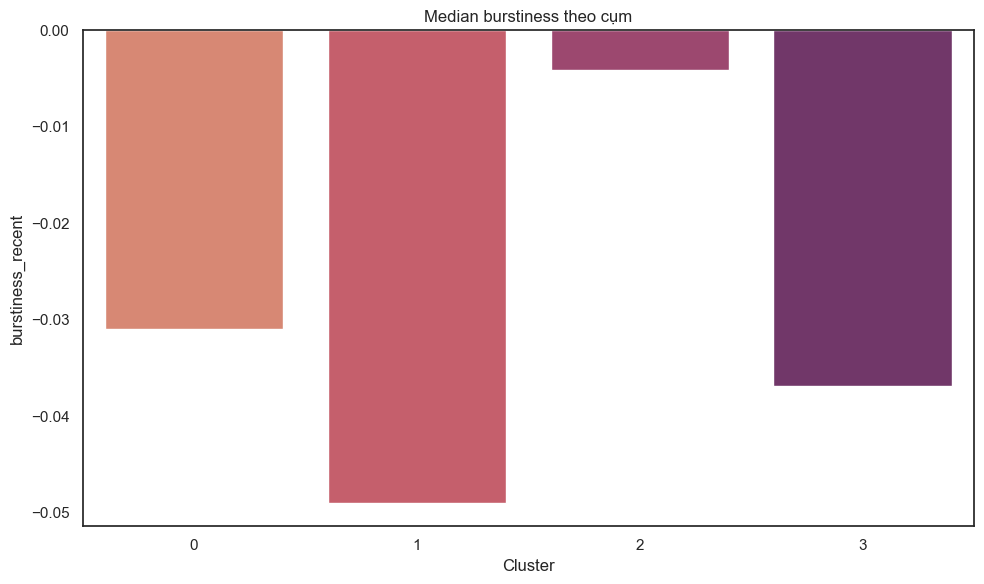

In [572]:
plot_burstiness = cluster_recent.sort_values('burstiness_recent_median', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_burstiness,
    x=cluster_col,
    y='burstiness_recent_median',
    palette='flare'
)
plt.title('Median burstiness theo cụm')
plt.xlabel('Cluster')
plt.ylabel('burstiness_recent')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\2823175585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


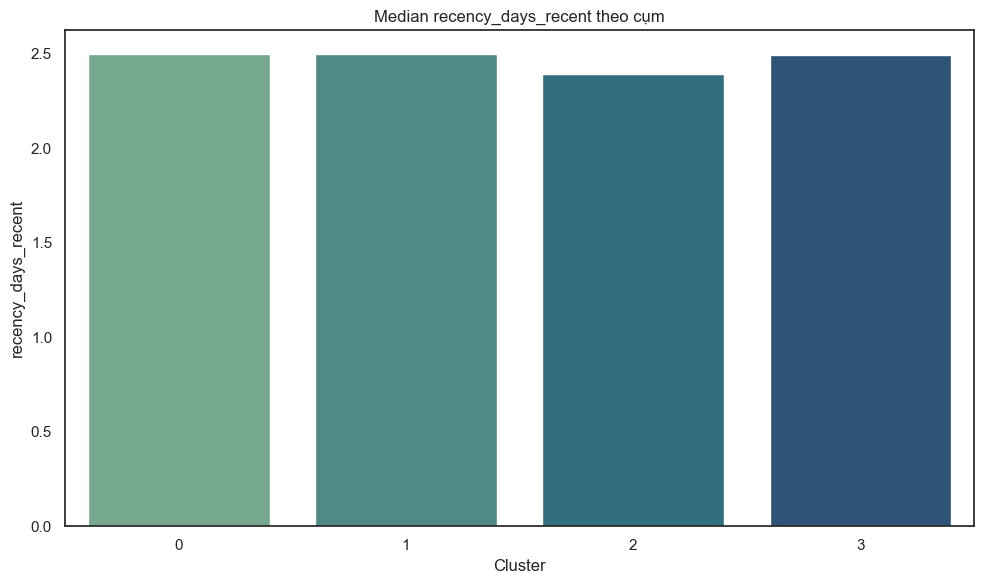

In [573]:
plot_recency = cluster_recent.sort_values('recency_days_recent_median', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_recency,
    x=cluster_col,
    y='recency_days_recent_median',
    palette='crest'
)
plt.title('Median recency_days_recent theo cụm')
plt.xlabel('Cluster')
plt.ylabel('recency_days_recent')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\2353887942.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


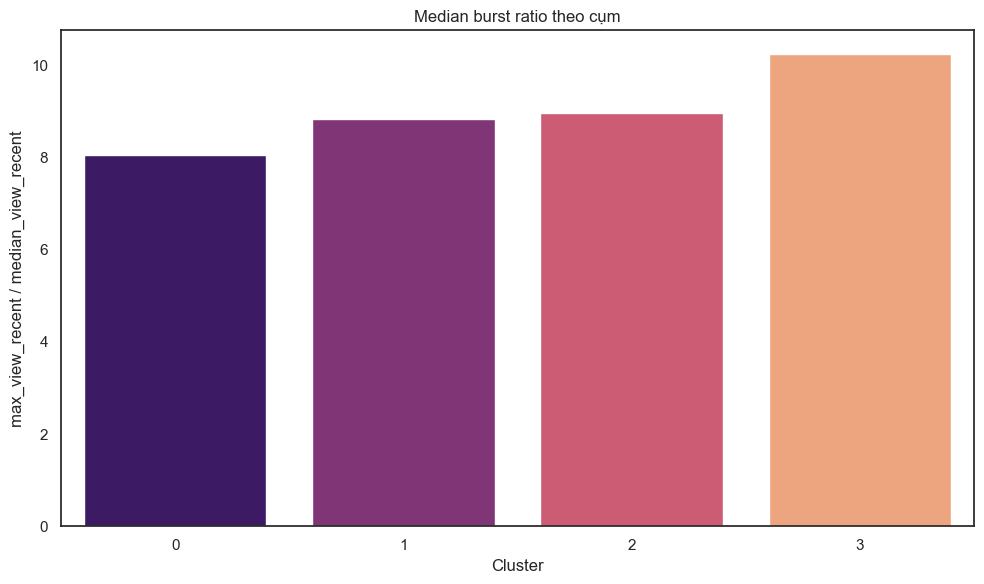

In [574]:
plot_burst_ratio = cluster_recent.sort_values('burst_ratio_median', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_burst_ratio,
    x=cluster_col,
    y='burst_ratio_median',
    palette='magma'
)
plt.title('Median burst ratio theo cụm')
plt.xlabel('Cluster')
plt.ylabel('max_view_recent / median_view_recent')
plt.tight_layout()
plt.show()

In [575]:

cluster_col = 'cluster_kmeans'

cluster_active = (
    df.groupby(cluster_col)
      .agg(
          n=('handleName', 'count'),
          active_active_mean=('active_active', 'mean'),
          active_active_median=('active_active', 'median'),
          engagement_mean=('engagementRate', 'mean'),
          engagement_median=('engagementRate', 'median')
      )
      .reset_index()
      .sort_values('active_active_mean', ascending=False)
)

print(cluster_active)

   cluster_kmeans     n  active_active_mean  active_active_median  \
3               3    13            0.666389              0.702390   
1               1  3966            0.643797              0.691654   
2               2   322            0.640085              0.659890   
0               0   788            0.490581              0.504603   

   engagement_mean  engagement_median  
3         0.080438            0.06980  
1         0.059686            0.04620  
2         0.057747            0.05005  
0         0.041521            0.02970  


C:\Users\Admin\AppData\Local\Temp\ipykernel_1984\2903085461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


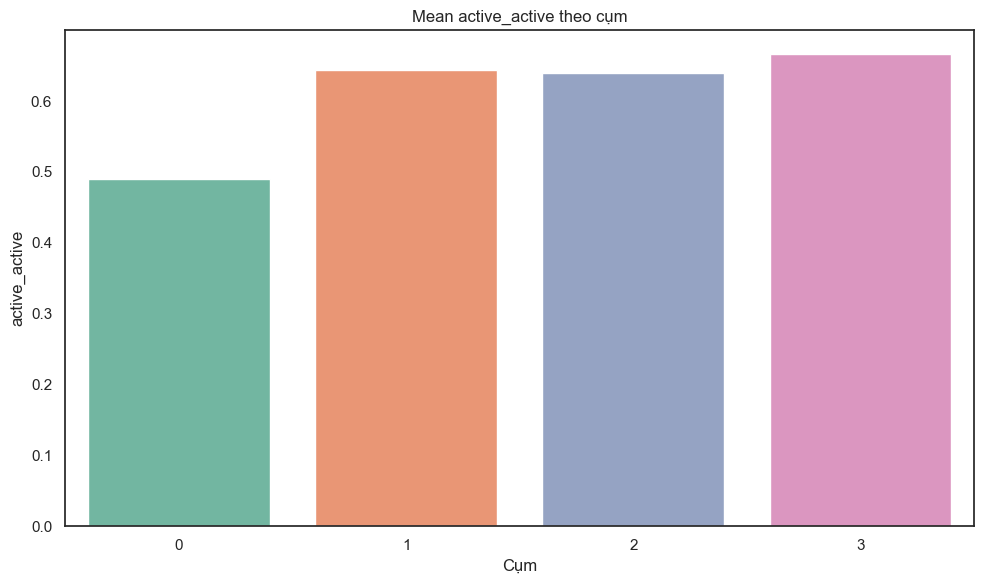

In [576]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cluster_active,
    x=cluster_col,
    y='active_active_mean',
    palette='Set2'
)

plt.title('Mean active_active theo cụm')
plt.xlabel('Cụm')
plt.ylabel('active_active')
plt.tight_layout()
plt.show()

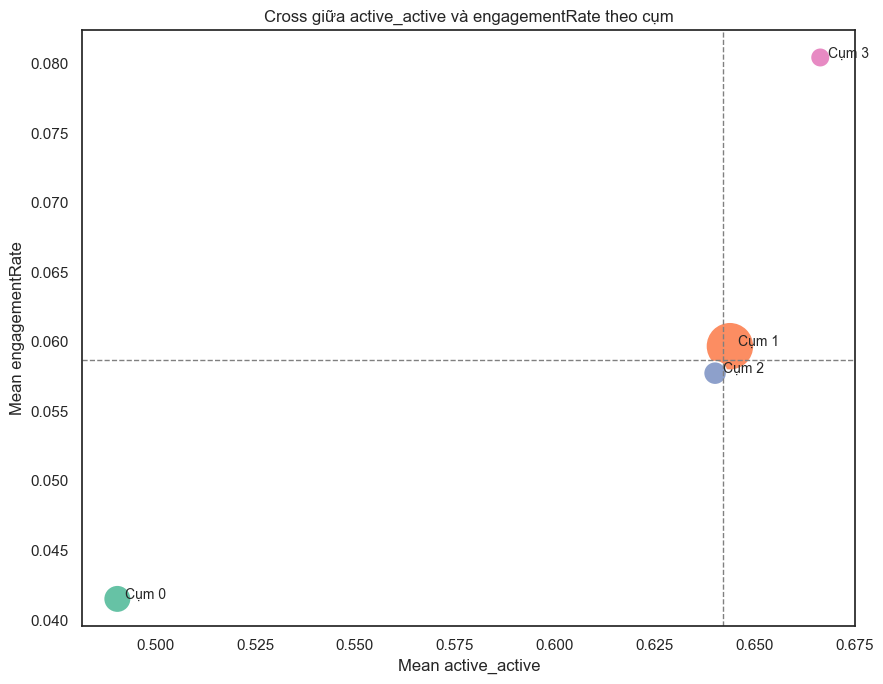

In [577]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=cluster_active,
    x='active_active_mean',
    y='engagement_mean',
    size='n',
    sizes=(200, 1200),
    hue=cluster_col,
    palette='Set2',
    legend=False
)

# đường median để chia quadrant
x_cut = cluster_active['active_active_mean'].median()
y_cut = cluster_active['engagement_mean'].median()

plt.axvline(x_cut, color='gray', linestyle='--', linewidth=1)
plt.axhline(y_cut, color='gray', linestyle='--', linewidth=1)

for _, row in cluster_active.iterrows():
    plt.text(
        row['active_active_mean'] + 0.002,
        row['engagement_mean'],
        f"Cụm {int(row[cluster_col])}",
        fontsize=10
    )

plt.title('Cross giữa active_active và engagementRate theo cụm')
plt.xlabel('Mean active_active')
plt.ylabel('Mean engagementRate')
plt.tight_layout()
plt.show()

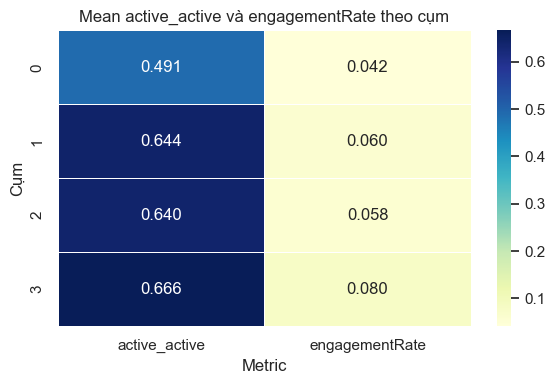

In [578]:
heatmap_df = (
    df.groupby(cluster_col)[['active_active', 'engagementRate']]
      .mean()
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Mean active_active và engagementRate theo cụm')
plt.xlabel('Metric')
plt.ylabel('Cụm')
plt.tight_layout()
plt.show()

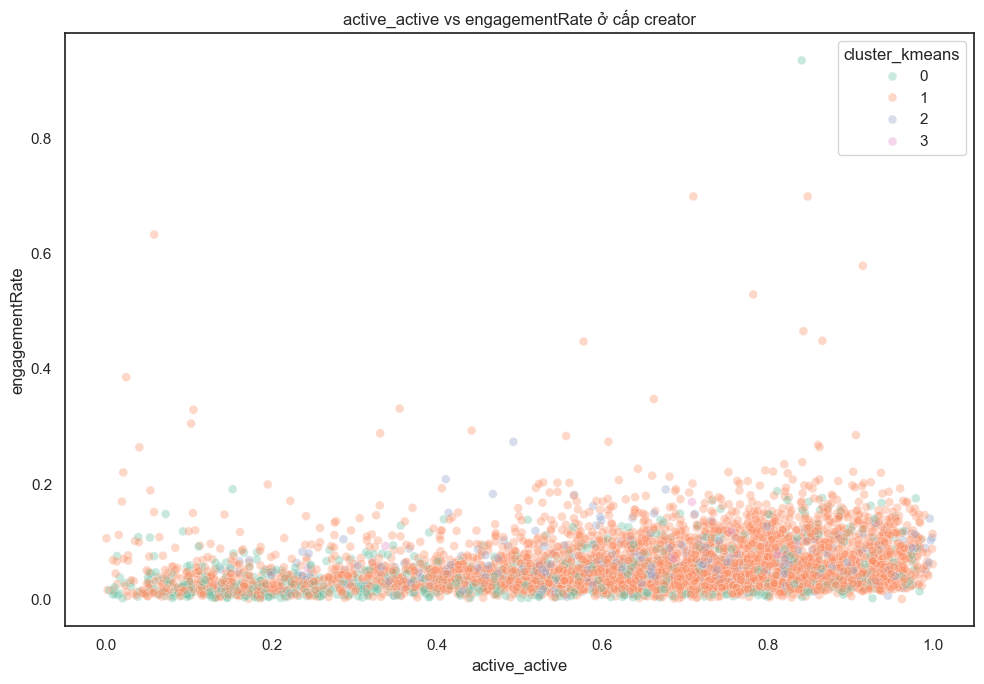

In [579]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='active_active',
    y='engagementRate',
    hue=cluster_col,
    palette='Set2',
    alpha=0.35,
    s=40
)

plt.title('active_active vs engagementRate ở cấp creator')
plt.xlabel('active_active')
plt.ylabel('engagementRate')
plt.tight_layout()
plt.show()